<a href="https://colab.research.google.com/github/arvnkl/da_projects/blob/main/telco_customer_segmentation_and_churn_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

In this project, we will work with the [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) dataset to analyze customer churn and form churn mitigation recommendations.

Main steps:

1) Data preprocessing and exploration;

2) K-means clustering to outline customer segments;

3) Logistic regression to predict churn (for a segment with the highest churn);

4) Churn mitigation recommendations based on exploratory data analysis and logistic regression for the highest-churn segment.

Main libraries: `dplyr`, `ggplot2`, `factoextra`, `MASS`, `caret`.

# Data preprocessing and exploration

Our dataset has 21 variables and 7043 observations. The variables are described on Kaggle as follows:

0)  ID:

- `customerID`

1) Demographic variables:

- `gender` - customer’s gender

- `SeniorCitizen` - whether the customer is a senior citizen or not (1, 0)

- `Partner` - whether the customer has a partner or not (Yes, No)

- `Dependents` - whether the customer has dependents or not (Yes, No)

2) Services provided:

- `PhoneService` - whether the customer has a phone service or not (Yes, No)

  - `MultipleLines` - whether the customer has multiple lines or not (Yes, No, No phone service)

- `InternetService` - customer’s internet service provider (DSL, Fiber optic, No)

  - `OnlineSecurity` - whether the customer has online security or not (Yes, No, No internet service)

  - `OnlineBackup` - whether the customer has online backup or not (Yes, No, No internet service)

  - `DeviceProtection` - whether the customer has device protection or not (Yes, No, No internet service)

  - `TechSupport` - whether the customer has tech support or not (Yes, No, No internet service)

  - `StreamingTV` - whether the customer has streaming TV or not (Yes, No, No internet service)

  - `StreamingMovies` - whether the customer has streaming movies or not (Yes, No, No internet service)

3) Contract and payment details:

- `Contract` - customer's contract term (Month-to-month, One year, Two year)

- `PaperlessBilling` - whether the customer has paperless billing or not (Yes, No)

- `PaymentMethod` - customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic)

4) Tenure and charges details:

- `tenure` - number of months the customer has stayed with the company

- `MonthlyCharges` - amount charged to the customer monthly

- `TotalCharges` - total amount charged to the customer

5) The variable of interest:

- `Churn` - whether the customer has left the company within the last month (Yes or No)

## Data wrangling and cleaning

Importing libraries.

In [ ]:
library(readxl)
library(dplyr)
library(ggplot2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Let’s have a first look at our data and check/correct the variable types and coding.

In [ ]:
data <- read.csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
str(data)

'data.frame':	7043 obs. of  21 variables:
 $ customerID      : chr  "7590-VHVEG" "5575-GNVDE" "3668-QPYBK" "7795-CFOCW" ...
 $ gender          : chr  "Female" "Male" "Male" "Male" ...
 $ SeniorCitizen   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ Partner         : chr  "Yes" "No" "No" "No" ...
 $ Dependents      : chr  "No" "No" "No" "No" ...
 $ tenure          : int  1 34 2 45 2 8 22 10 28 62 ...
 $ PhoneService    : chr  "No" "Yes" "Yes" "No" ...
 $ MultipleLines   : chr  "No phone service" "No" "No" "No phone service" ...
 $ InternetService : chr  "DSL" "DSL" "DSL" "DSL" ...
 $ OnlineSecurity  : chr  "No" "Yes" "Yes" "Yes" ...
 $ OnlineBackup    : chr  "Yes" "No" "Yes" "No" ...
 $ DeviceProtection: chr  "No" "Yes" "No" "Yes" ...
 $ TechSupport     : chr  "No" "No" "No" "Yes" ...
 $ StreamingTV     : chr  "No" "No" "No" "No" ...
 $ StreamingMovies : chr  "No" "No" "No" "No" ...
 $ Contract        : chr  "Month-to-month" "One year" "Month-to-month" "One year" ...
 $ PaperlessBilling: chr  "Yes"

In [ ]:
data$SeniorCitizen <- if_else(data$SeniorCitizen == 1, "Yes", "No")

data[-c(1, 6, 19, 20)] <- lapply(data[-c(1, 6, 19, 20)], as.factor)
summary(data)

  customerID           gender     SeniorCitizen Partner    Dependents
 Length:7043        Female:3488   No :5901      No :3641   No :4933  
 Class :character   Male  :3555   Yes:1142      Yes:3402   Yes:2110  
 Mode  :character                                                    
                                                                     
                                                                     
                                                                     
                                                                     
     tenure      PhoneService          MultipleLines     InternetService
 Min.   : 0.00   No : 682     No              :3390   DSL        :2421  
 1st Qu.: 9.00   Yes:6361     No phone service: 682   Fiber optic:3096  
 Median :29.00                Yes             :2971   No         :1526  
 Mean   :32.37                                                          
 3rd Qu.:55.00                                                          
 M

In [ ]:
# checking how many missing values are there
missing_values <- sum(is.na(data))
missing_values

[1] 11

We can notice 11 missing values in `TotalCharges`, let's take a closer look at these observations.

In [ ]:
# share of missing values
round(missing_values/nrow(data)*100, 1)

[1] 0.2

11 missing values constitute approximately 0.2% of the dataset.

In [ ]:
data %>% filter(is.na(TotalCharges))

customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,⋯,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
<chr>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<fct>
4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,⋯,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NA,No
3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NA,No
5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,⋯,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NA,No
4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NA,No
1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,⋯,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NA,No
7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NA,No
3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NA,No
2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NA,No
2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NA,No


In [ ]:
summary(data %>% filter(tenure == 0))

  customerID           gender  SeniorCitizen Partner Dependents     tenure 
 Length:11          Female:5   No :11        No :2   No : 0     Min.   :0  
 Class :character   Male  :6   Yes: 0        Yes:9   Yes:11     1st Qu.:0  
 Mode  :character                                               Median :0  
                                                                Mean   :0  
                                                                3rd Qu.:0  
                                                                Max.   :0  
                                                                           
 PhoneService          MultipleLines    InternetService
 No :2        No              :5     DSL        :5     
 Yes:9        No phone service:2     Fiber optic:0     
              Yes             :4     No         :6     
                                                       
                                                       
                                                       


In [ ]:
count(data %>% filter(tenure < 1))

n
<int>
11


In [ ]:
summary(data$tenure)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    9.00   29.00   32.37   55.00   72.00 

These 11 customers have `tenure` of 0 months, hence, their `TotalCharges` are NA's and they only have `MonthlyCharges` column filled. For the sake of simplicity we are going to fill `TotalCharges` of these 11 customers with values from `MonthlyCharges`.

In [ ]:
data_full <- data

In [ ]:
data_full$TotalCharges[is.na(data_full$TotalCharges)] <- data_full$MonthlyCharges[is.na(data_full$TotalCharges)]

In [ ]:
data_full %>% filter(tenure == 0)

customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,⋯,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
<chr>,<fct>,<fct>,<fct>,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<fct>
4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,⋯,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,52.55,No
3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,20.25,No
5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,⋯,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,80.85,No
4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,25.75,No
1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,⋯,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,56.05,No
7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,19.85,No
3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,25.35,No
2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,20.00,No
2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,⋯,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,19.70,No


The data is clean now so let's move on to data visualization.

## Data visualization by churn

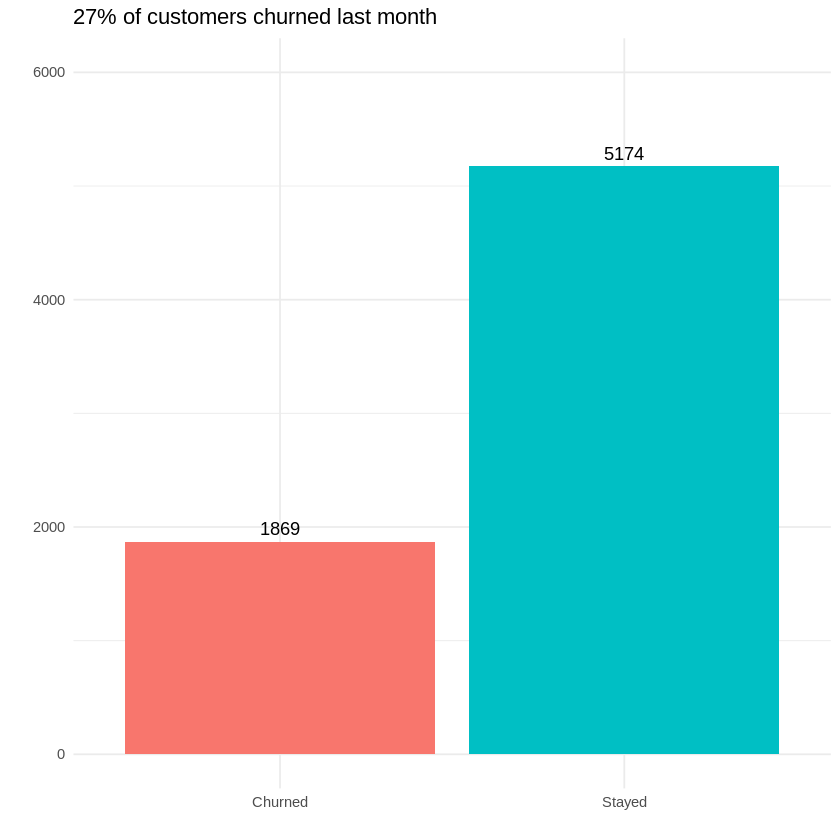

In [ ]:
data_full$Churn <- relevel(data_full$Churn, ref = "Yes")

# to enable visual comparison across categorical variables,
# all subsequent bar charts share a fixed y-axis range (0-6000)

ggplot(data_full, aes(Churn, fill = Churn)) +
geom_bar() +
ggtitle("27% of customers churned last month") +
ylab("") +
xlab("") +
scale_y_continuous(limits = c(0, 6000)) +
geom_text(aes(label = after_stat(count)), stat = "count", vjust = -0.5) +
theme_minimal() +
theme(legend.position = "none") +
scale_x_discrete(labels = c("No" = "Stayed", "Yes" = "Churned"))

Out of 7043 customers **27% have churned**.

### Demographic info

Now, let’s look at customer churn in relation to demographic, service, and account information.

In [ ]:
# this library will help patch multiple graphs together
install.packages("patchwork")
library(patchwork)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



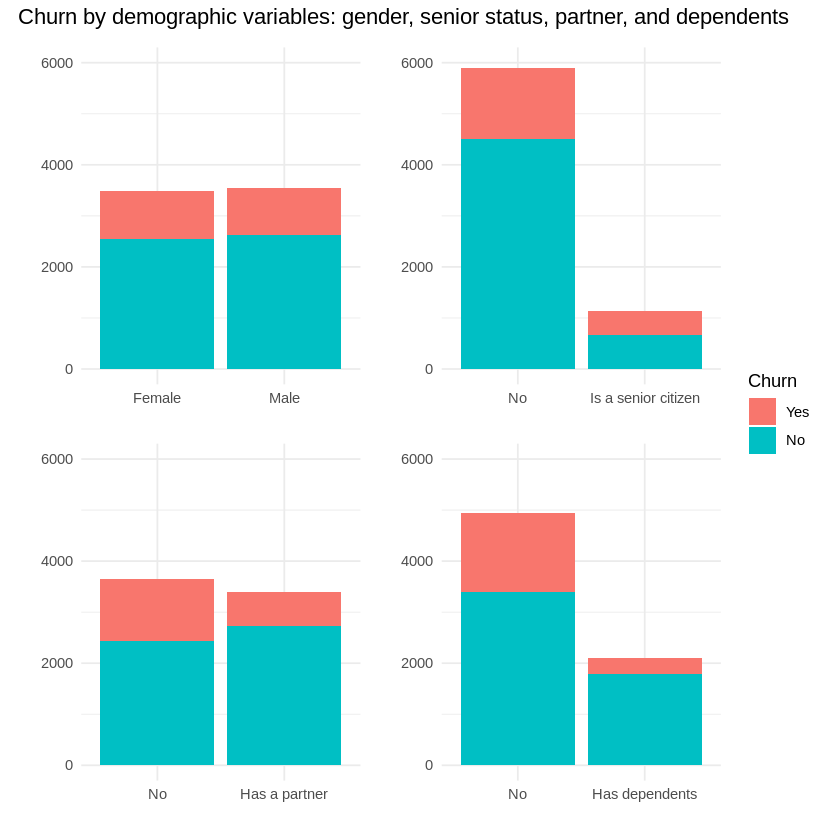

In [ ]:
p1 <- ggplot(data_full, aes(fill = Churn, x = gender)) +
  geom_bar(position = "stack") +
  xlab("") +
  ylab("") +
  scale_y_continuous(limits = c(0, 6000)) +
  theme_minimal()

p2 <- ggplot(data_full, aes(fill = Churn, x = SeniorCitizen)) +
  geom_bar(position = "stack") +
  xlab("") +
  ylab("") +
  scale_y_continuous(limits = c(0, 6000)) +
  theme_minimal() +
  scale_x_discrete(labels = c("No" = "No", "Yes" = "Is a senior citizen"))

p3 <- ggplot(data_full, aes(fill = Churn, x = Partner)) +
  geom_bar(position = "stack") +
  xlab("") +
  ylab("") +
  scale_y_continuous(limits = c(0, 6000)) +
  theme_minimal() +
  scale_x_discrete(labels = c("No" = "No", "Yes" = "Has a partner"))

p4 <- ggplot(data_full, aes(fill = Churn, x = Dependents)) +
  geom_bar(position = "stack") +
  xlab("") +
  ylab("") +
  scale_y_continuous(limits = c(0, 6000)) +
  theme_minimal() +
  scale_x_discrete(labels = c("No" = "No", "Yes" = "Has dependents"))

p1 + p2 + p3 + p4 +
  plot_annotation(title = "Churn by demographic variables: gender, senior status, partner, and dependents") +
  plot_layout(guides = "collect")

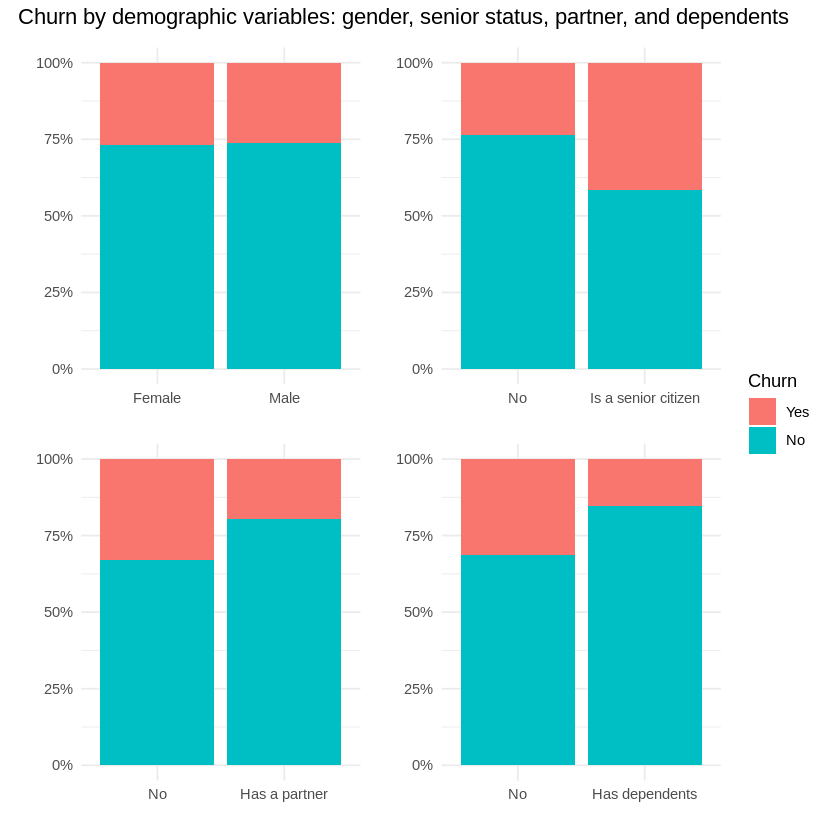

In [ ]:
p1 <- ggplot(data_full, aes(fill = Churn, x = gender)) +
  geom_bar(position = "fill") + xlab("") + scale_y_continuous(labels = scales::percent) + ylab(" ") +
  theme_minimal()

p2 <- ggplot(data_full, aes(fill = Churn, x = SeniorCitizen)) +
  geom_bar(position = "fill") + xlab("") + scale_y_continuous(labels = scales::percent) + ylab(" ") +
  theme_minimal() + scale_x_discrete(labels = c("No" = "No", "Yes" = "Is a senior citizen"))

p3 <- ggplot(data_full, aes(fill = Churn, x = Partner)) +
  geom_bar(position = "fill") + xlab("") + scale_y_continuous(labels = scales::percent) + ylab(" ") +
  theme_minimal() + scale_x_discrete(labels = c("No" = "No", "Yes" = "Has a partner"))

p4 <- ggplot(data_full, aes(fill = Churn, x = Dependents)) +
  geom_bar(position = "fill") + xlab("") + scale_y_continuous(labels = scales::percent) + ylab(" ") +
  theme_minimal() + scale_x_discrete(labels = c("No" = "No", "Yes" = "Has dependents"))

p1 + p2 + p3 + p4 + plot_annotation(title = "Churn by demographic variables: gender, senior status, partner, and dependents") + plot_layout(guides = "collect")

In [ ]:
data_full %>%
  group_by(gender, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(gender) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(SeniorCitizen, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(SeniorCitizen) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(Partner, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(Partner) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(Dependents, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(Dependents) %>%
  mutate(percentage = count / sum(count) * 100)

gender,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
Female,Yes,939,26.92087
Female,No,2549,73.07913
Male,Yes,930,26.16034
Male,No,2625,73.83966


SeniorCitizen,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,1393,23.60617
No,No,4508,76.39383
Yes,Yes,476,41.68126
Yes,No,666,58.31874


Partner,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,1200,32.95798
No,No,2441,67.04202
Yes,Yes,669,19.66490
Yes,No,2733,80.33510


Dependents,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,1543,31.27914
No,No,3390,68.72086
Yes,Yes,326,15.45024
Yes,No,1784,84.54976


- **Senior citizens** constitute only 16% of our data, however, churn among them (42%) is higher than among non-seniors (24%);

- Number of customers **without a partner** (52%) is almost similar to those with one (48%). Among partnerless clients churn is higher (33%) than among those with a partner (20%).

- Most customers **did not have dependents** (70%). Churn among them were higher (31%) than among those with dependents (15%).

- Customers were evenly distributed by gender (50% each), with similar churn rates across both groups (26-27%).


### Services signed up for

#### Phone services

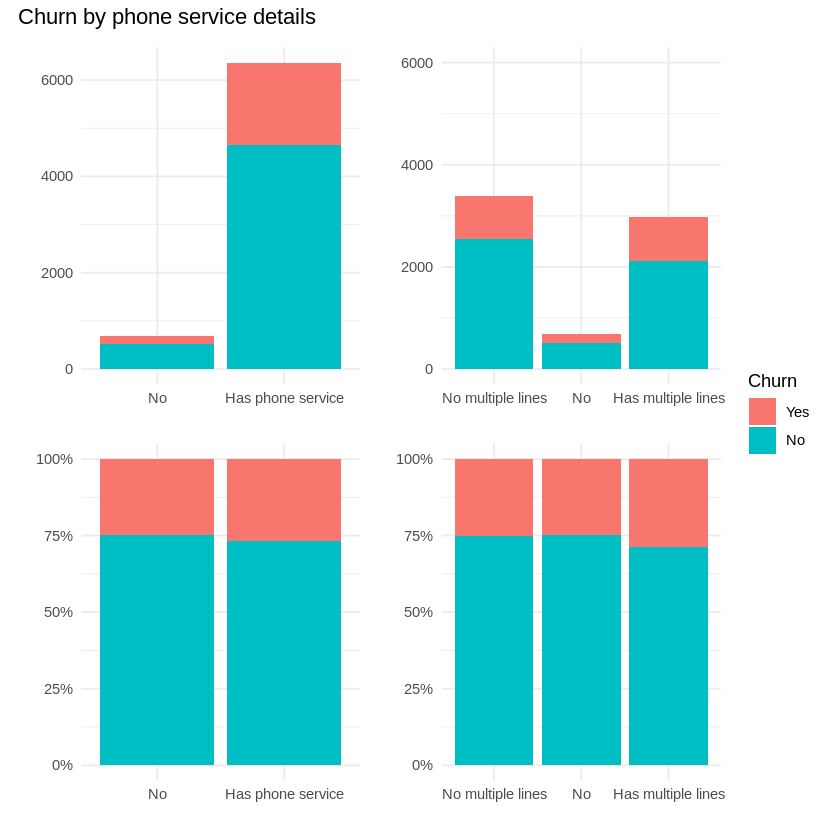

In [ ]:
p6 <- ggplot(data_full, aes(fill = Churn, x = PhoneService)) +
  geom_bar(position = "stack") + ylab("") + xlab("") + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No", "Yes" = "Has phone service"))

p7 <- ggplot(data_full, aes(fill = Churn, x = MultipleLines)) +
  geom_bar(position = "stack") + ylab("") + xlab("") + scale_y_continuous(limits = c(0, 6000)) + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No multiple lines", "Yes" = "Has multiple lines", "No phone service" = "No"))

p67 <- ggplot(data_full, aes(fill = Churn, x = PhoneService)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + ylab("") + xlab("") + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No", "Yes" = "Has phone service"))

p72 <- ggplot(data_full, aes(fill = Churn, x = MultipleLines)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + ylab("") + xlab("") + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No multiple lines", "Yes" = "Has multiple lines", "No phone service" = "No"))

p6 + p7 + p67 +p72 + plot_annotation(title = "Churn by phone service details") + plot_layout(guides = "collect")

In [ ]:
data_full %>%
  group_by(PhoneService, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(PhoneService) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(MultipleLines, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(MultipleLines) %>%
  mutate(percentage = count / sum(count) * 100)

PhoneService,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,170,24.92669
No,No,512,75.07331
Yes,Yes,1699,26.70964
Yes,No,4662,73.29036


MultipleLines,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,849,25.04425
No,No,2541,74.95575
No phone service,Yes,170,24.92669
No phone service,No,512,75.07331
Yes,Yes,850,28.60990
Yes,No,2121,71.39010


- 90% of customers have phone service signed up for. Churn rates are nearly identical among customers with and without it (25-27%), matching the overall dataset churn rate (27%).

- Among those with phone service 53% have multiple lines on. Churn rates between phone service clients with multiple lines (25%) and without it (29%) are also matching the overall churn rate.

#### Internet services

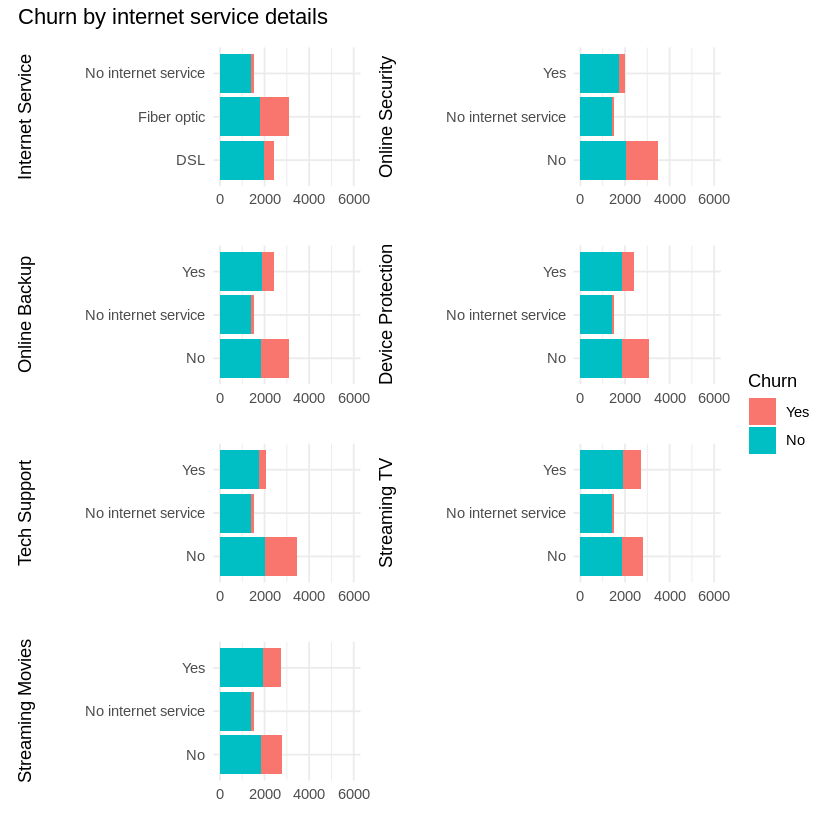

In [ ]:
p8 <- ggplot(data_full, aes(fill = Churn, x = InternetService)) +
  geom_bar(position = "stack") + ylab(" ") + coord_flip() + scale_y_continuous(limits = c(0, 6000)) + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No internet service")) + xlab("Internet Service")

p9 <- ggplot(data_full, aes(fill = Churn, x = OnlineSecurity)) +
  geom_bar(position = "stack") + ylab(" ") + coord_flip() + scale_y_continuous(limits = c(0, 6000)) + theme_minimal() +
  xlab("Online Security")

p10 <- ggplot(data_full, aes(fill = Churn, x = OnlineBackup)) +
  geom_bar(position = "stack") + ylab(" ") + coord_flip() + scale_y_continuous(limits = c(0, 6000)) + theme_minimal() +
  xlab("Online Backup")

p11 <- ggplot(data_full, aes(fill = Churn, x = DeviceProtection)) +
  geom_bar(position = "stack") + ylab(" ") + coord_flip() + scale_y_continuous(limits = c(0, 6000)) + theme_minimal() +
  xlab("Device Protection")

p12 <- ggplot(data_full, aes(fill = Churn, x = TechSupport)) +
  geom_bar(position = "stack") + ylab(" ") + coord_flip() + scale_y_continuous(limits = c(0, 6000)) + theme_minimal() +
  xlab("Tech Support")

p13 <- ggplot(data_full, aes(fill = Churn, x = StreamingTV)) +
  geom_bar(position = "stack") + ylab(" ") + coord_flip() + scale_y_continuous(limits = c(0, 6000)) + theme_minimal() +
  xlab("Streaming TV")

p14 <- ggplot(data_full, aes(fill = Churn, x = StreamingMovies)) +
  geom_bar(position = "stack") + ylab(" ") + coord_flip() + scale_y_continuous(limits = c(0, 6000)) + theme_minimal() +
  xlab("Streaming Movies")

p8 + p9 + p10 + p11 + p12 + p13 + p14 + plot_annotation(title = "Churn by internet service details") + plot_layout(nrow = 4, guides = "collect")

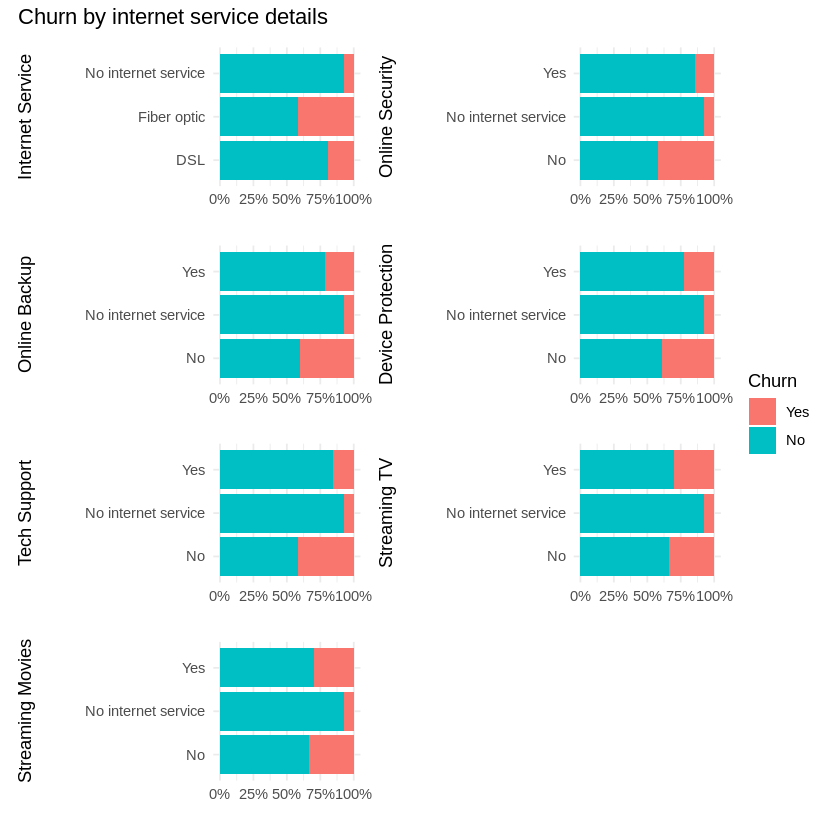

In [ ]:
p8 <- ggplot(data_full, aes(fill = Churn, x = InternetService)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + xlab("Internet Service") + coord_flip() + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No internet service")) + ylab("")

p9 <- ggplot(data_full, aes(fill = Churn, x = OnlineSecurity)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + ylab(" ") + coord_flip() + theme_minimal() + xlab("Online Security")

p10 <- ggplot(data_full, aes(fill = Churn, x = OnlineBackup)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + ylab(" ") + coord_flip() + theme_minimal() + xlab("Online Backup")

p11 <- ggplot(data_full, aes(fill = Churn, x = DeviceProtection)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + ylab(" ") + coord_flip() + theme_minimal() + xlab("Device Protection")

p12 <- ggplot(data_full, aes(fill = Churn, x = TechSupport)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + ylab(" ") + coord_flip() + theme_minimal() + xlab("Tech Support")

p13 <- ggplot(data_full, aes(fill = Churn, x = StreamingTV)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + ylab(" ") + coord_flip() + theme_minimal() + xlab("Streaming TV")

p14 <- ggplot(data_full, aes(fill = Churn, x = StreamingMovies)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + ylab(" ") + coord_flip() + theme_minimal() + xlab("Streaming Movies")

p8 + p9 + p10 + p11 + p12 + p13 + p14 + plot_annotation(title = "Churn by internet service details") + plot_layout(nrow = 4, guides = "collect")

In [ ]:
data_full %>%
  group_by(InternetService, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(InternetService) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(OnlineBackup, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(OnlineBackup) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(OnlineSecurity, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(OnlineSecurity) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(DeviceProtection, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(DeviceProtection) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(TechSupport, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(TechSupport) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(StreamingTV, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(StreamingTV) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(StreamingMovies, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(StreamingMovies) %>%
  mutate(percentage = count / sum(count) * 100)

InternetService,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
DSL,Yes,459,18.95911
DSL,No,1962,81.04089
Fiber optic,Yes,1297,41.89276
Fiber optic,No,1799,58.10724
No,Yes,113,7.40498
No,No,1413,92.59502


OnlineBackup,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,1233,39.92876
No,No,1855,60.07124
No internet service,Yes,113,7.40498
No internet service,No,1413,92.59502
Yes,Yes,523,21.53149
Yes,No,1906,78.46851


OnlineSecurity,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,1461,41.76672
No,No,2037,58.23328
No internet service,Yes,113,7.40498
No internet service,No,1413,92.59502
Yes,Yes,295,14.61119
Yes,No,1724,85.38881


DeviceProtection,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,1211,39.12763
No,No,1884,60.87237
No internet service,Yes,113,7.40498
No internet service,No,1413,92.59502
Yes,Yes,545,22.50206
Yes,No,1877,77.49794


TechSupport,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,1446,41.63547
No,No,2027,58.36453
No internet service,Yes,113,7.40498
No internet service,No,1413,92.59502
Yes,Yes,310,15.16634
Yes,No,1734,84.83366


StreamingTV,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,942,33.52313
No,No,1868,66.47687
No internet service,Yes,113,7.40498
No internet service,No,1413,92.59502
Yes,Yes,814,30.07019
Yes,No,1893,69.92981


StreamingMovies,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,938,33.68043
No,No,1847,66.31957
No internet service,Yes,113,7.40498
No internet service,No,1413,92.59502
Yes,Yes,818,29.94143
Yes,No,1914,70.05857


In [ ]:
summary(data_full[c(9:15)])

    InternetService             OnlineSecurity              OnlineBackup 
 DSL        :2421   No                 :3498   No                 :3088  
 Fiber optic:3096   No internet service:1526   No internet service:1526  
 No         :1526   Yes                :2019   Yes                :2429  
            DeviceProtection              TechSupport  
 No                 :3095    No                 :3473  
 No internet service:1526    No internet service:1526  
 Yes                :2422    Yes                :2044  
              StreamingTV              StreamingMovies
 No                 :2810   No                 :2785  
 No internet service:1526   No internet service:1526  
 Yes                :2707   Yes                :2732  

- 78% had internet service (5517 customers). Out of those with internet service, 44% have DSL option and 56% have the fiber optic option. Churn rate was higher among **fiber optic users** (42%) than those with the DSL option (19%);

 - Out of those with internet service 37% have online security, 44% have online backup, 44% have device protection, 37% have tech support, 49% have streaming TV, and 50% have streaming movies;

 - Churn was higher among clietns without tech support (42%), device protection (39%), online backup (40%) and online security (42%) than those with them (15%, 23%, 22%, and 15% respectively).

### Contract type, billing, and payment method

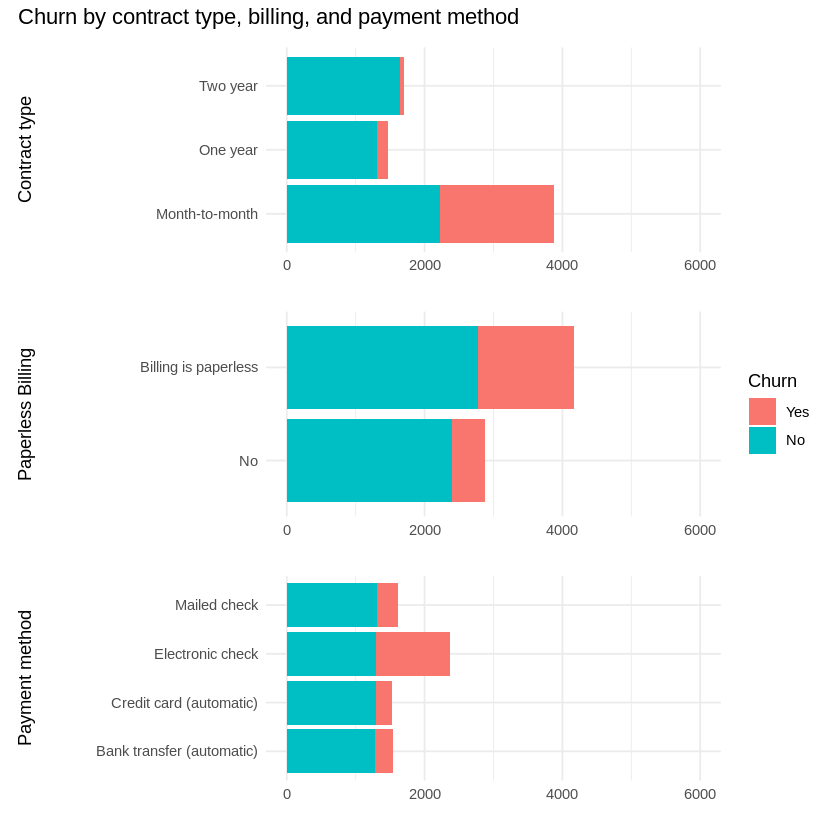

In [ ]:
p15 <- ggplot(data_full, aes(fill = Churn, x = Contract)) +
  geom_bar(position = "stack") + coord_flip() + ylab(" ") + xlab("Contract type") + scale_y_continuous(limits = c(0, 6000))  + theme_minimal()

p16 <- ggplot(data_full, aes(fill = Churn, x = PaperlessBilling)) +
  geom_bar(position = "stack") + coord_flip() + xlab("Paperless Billing") + ylab(" ") + scale_y_continuous(limits = c(0, 6000)) + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No", "Yes" = "Billing is paperless"))

p17 <- ggplot(data_full, aes(fill = Churn, x = PaymentMethod)) +
  geom_bar(position = "stack") + coord_flip() + ylab(" ") + xlab("Payment method") + scale_y_continuous(limits = c(0, 6000)) + theme_minimal()

p15 + p16 + p17 + plot_annotation(title = "Churn by contract type, billing, and payment method") + plot_layout(nrow = 3, guides = "collect")

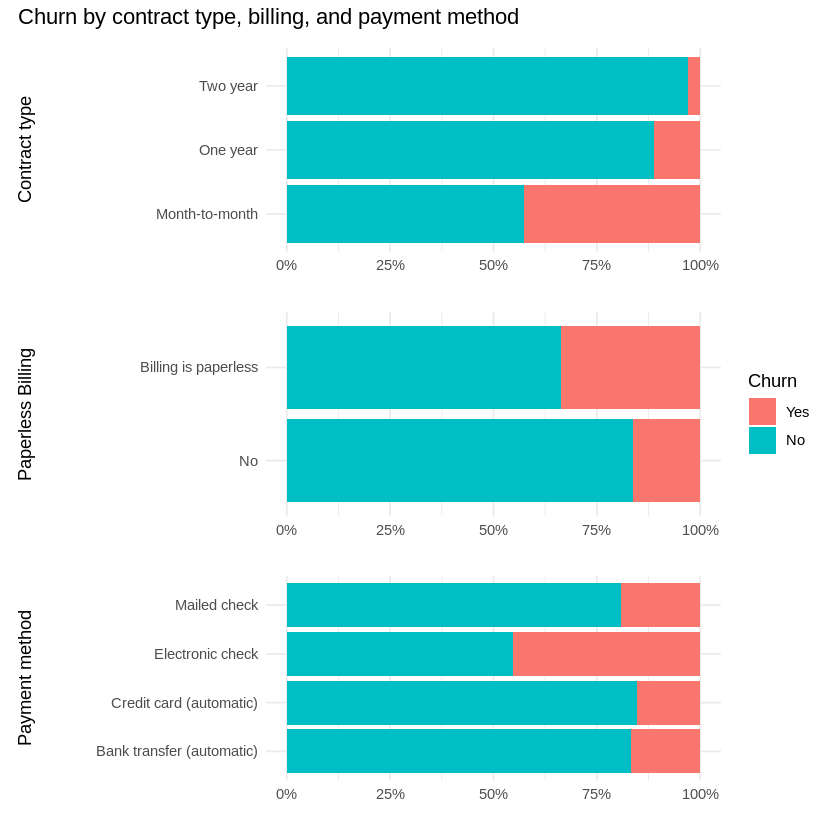

In [ ]:
p15 <- ggplot(data_full, aes(fill = Churn, x = Contract)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + coord_flip() + ylab(" ") + xlab("Contract type") +
  theme_minimal()

p16 <- ggplot(data_full, aes(fill = Churn, x = PaperlessBilling)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + coord_flip() + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No", "Yes" = "Billing is paperless")) + xlab("Paperless Billing") + ylab("")

p17 <- ggplot(data_full, aes(fill = Churn, x = PaymentMethod)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + coord_flip() + ylab(" ") + xlab("Payment method") +
  theme_minimal()

p15 + p16 + p17 + plot_annotation(title = "Churn by contract type, billing, and payment method") + plot_layout(nrow = 3, guides = "collect")

In [ ]:
data_full %>%
  group_by(Contract, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(Contract) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(PaperlessBilling, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(PaperlessBilling) %>%
  mutate(percentage = count / sum(count) * 100)

data_full %>%
  group_by(PaymentMethod, Churn) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(PaymentMethod) %>%
  mutate(percentage = count / sum(count) * 100)

Contract,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
Month-to-month,Yes,1655,42.709677
Month-to-month,No,2220,57.290323
One year,Yes,166,11.269518
One year,No,1307,88.730482
Two year,Yes,48,2.831858
Two year,No,1647,97.168142


PaperlessBilling,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
No,Yes,469,16.33008
No,No,2403,83.66992
Yes,Yes,1400,33.56509
Yes,No,2771,66.43491


PaymentMethod,Churn,count,percentage
<fct>,<fct>,<int>,<dbl>
Bank transfer (automatic),Yes,258,16.70984
Bank transfer (automatic),No,1286,83.29016
Credit card (automatic),Yes,232,15.24310
Credit card (automatic),No,1290,84.75690
Electronic check,Yes,1071,45.28541
Electronic check,No,1294,54.71459
Mailed check,Yes,308,19.10670
Mailed check,No,1304,80.89330


In [ ]:
summary(data_full[c(16:18)])

           Contract    PaperlessBilling                   PaymentMethod 
 Month-to-month:3875   No :2872         Bank transfer (automatic):1544  
 One year      :1473   Yes:4171         Credit card (automatic)  :1522  
 Two year      :1695                    Electronic check         :2365  
                                        Mailed check             :1612  

- Most clients have month-to-month contracts (55%). One year and two year contracts constitute 21% and 24% of the dataset respectively. Churn was higher among clients with **month-to-month contracts** (43%). Churn rate for one and two year options were 11% and 3% respectively;

- 59% have paperless billing. Churn rate was higher among clients with **paperless billing** (34%) than those without it (16%);

- Shares of payment methods were as follows:
  - 22% bank transfer (automatic),
  - 22% credit card (automatic),
  - 34% electronic check,
  - 23% mailed check.
  
  Churn was higher among clients with the **electronic check** option (45%). Churn rate for bank transfer (automatic), credit card (automatic), and mailed check options were 17%, 15%, and 19% respectively.

### Tenure, monthly and total charges

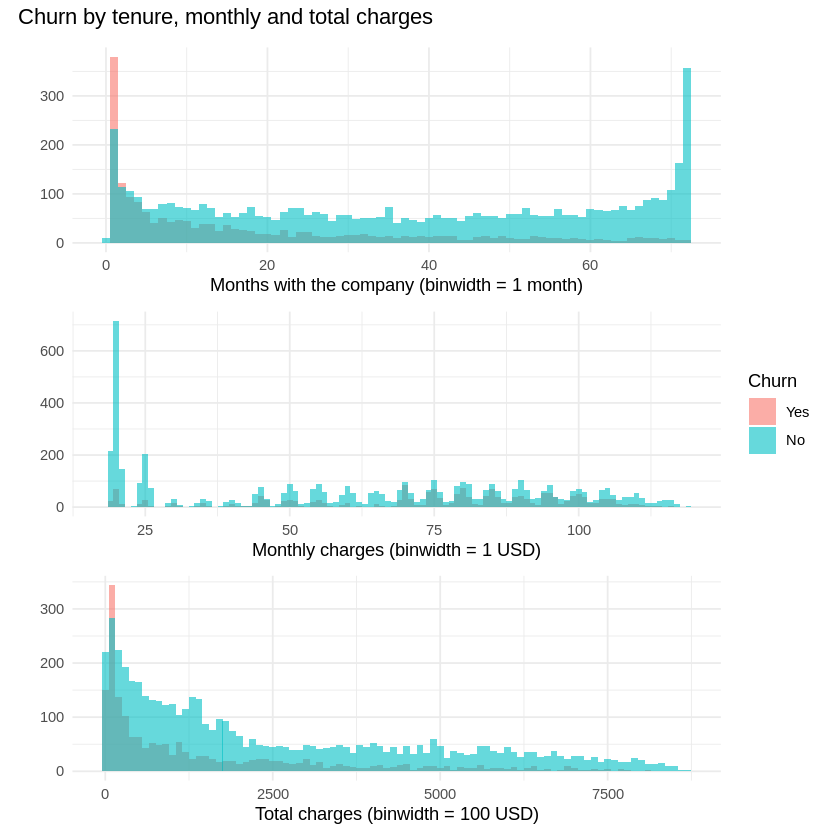

In [ ]:
p5 <- ggplot(data_full, aes(fill = Churn, x = tenure)) +
  geom_histogram(position = "identity", alpha = 0.6, binwidth = 1) + xlab("Months with the company (binwidth = 1 month)") + ylab("") + theme_minimal()

p18 <- ggplot(data_full, aes(fill = Churn, x = MonthlyCharges)) +
  geom_histogram(position = "identity", alpha = 0.6, binwidth = 1) + xlab("Monthly charges (binwidth = 1 USD)") + ylab("") + theme_minimal()

p19 <- ggplot(data_full, aes(fill = Churn, x = TotalCharges)) +
  geom_histogram(position = "identity", alpha = 0.6, binwidth = 100) + xlab("Total charges (binwidth = 100 USD)") + ylab("") + theme_minimal()

p5 + p18 + p19 + plot_annotation(title = "Churn by tenure, monthly and total charges") + plot_layout(nrow = 3, guides = "collect")

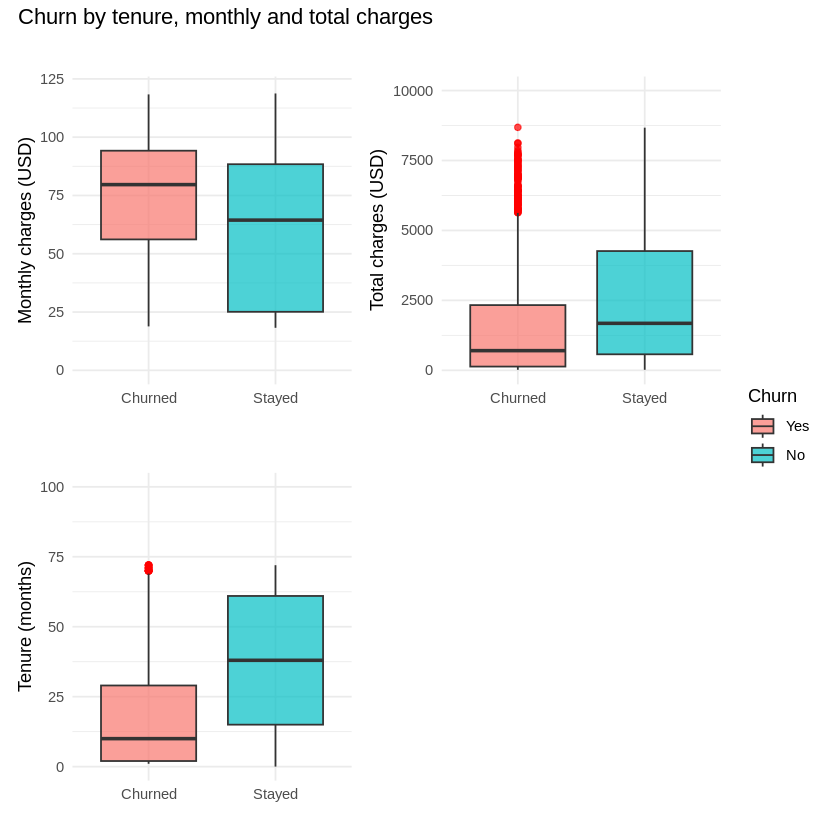

In [ ]:
p5 <- ggplot(data_full, aes(x = Churn, y = tenure, fill = Churn)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red") +
  labs(title = "", x = "", y = "Tenure (months)") + theme_minimal() +
  scale_x_discrete(labels = c("No" = "Stayed", "Yes" = "Churned")) +
  scale_y_continuous(limits = c(0, 100))

p18 <- ggplot(data_full, aes(x = Churn, y = MonthlyCharges, fill = Churn)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red") +
  labs(title = "", x = "", y = "Monthly charges (USD)") +
  theme_minimal() +
  scale_x_discrete(labels = c("No" = "Stayed", "Yes" = "Churned")) +
  scale_y_continuous(limits = c(0, 120))

p19 <- ggplot(data_full, aes(x = Churn, y = TotalCharges, fill = Churn)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red") +
  labs(title = "", x = "", y = "Total charges (USD)") +
  theme_minimal() +
  scale_x_discrete(labels = c("No" = "Stayed", "Yes" = "Churned")) +
  scale_y_continuous(limits = c(0, 10000))

 p18 + p19 + p5 + plot_annotation(title = "Churn by tenure, monthly and total charges") + plot_layout(nrow = 2, ncol = 2, guides = "collect")

In [ ]:
summary(data_full[c("TotalCharges", "MonthlyCharges", "tenure")])

  TotalCharges    MonthlyCharges       tenure     
 Min.   :  18.8   Min.   : 18.25   Min.   : 0.00  
 1st Qu.: 398.6   1st Qu.: 35.50   1st Qu.: 9.00  
 Median :1394.5   Median : 70.35   Median :29.00  
 Mean   :2279.8   Mean   : 64.76   Mean   :32.37  
 3rd Qu.:3786.6   3rd Qu.: 89.85   3rd Qu.:55.00  
 Max.   :8684.8   Max.   :118.75   Max.   :72.00  

- The overall `tenure` ranges from 0 months to 72 months (6 years). Central 50% of customers have been with the company from 9 months to 4 years and 7 months. Mean and median `tenure` were 32 and 29 months respectively.

- The overall `MonthlyCharges` range from 18 USD to 119 USD. Central 50% of customers pay 36-90 USD monthly. Mean and median `MonthlyCharges` were 65 and 70 USD respectively.

- The overall `TotalCharges` range from 19 USD to 8685 USD. Central 50% of customers have paid 399-3787 USD in total. Mean and median `TotalCharges` were 2280 and 1395 USD respectively.

In [ ]:
by(data_full[c("TotalCharges", "MonthlyCharges", "tenure")], data_full$Churn, summary)

data_full$Churn: Yes
  TotalCharges     MonthlyCharges       tenure     
 Min.   :  18.85   Min.   : 18.85   Min.   : 1.00  
 1st Qu.: 134.50   1st Qu.: 56.15   1st Qu.: 2.00  
 Median : 703.55   Median : 79.65   Median :10.00  
 Mean   :1531.80   Mean   : 74.44   Mean   :17.98  
 3rd Qu.:2331.30   3rd Qu.: 94.20   3rd Qu.:29.00  
 Max.   :8684.80   Max.   :118.35   Max.   :72.00  
------------------------------------------------------------ 
data_full$Churn: No
  TotalCharges    MonthlyCharges       tenure     
 Min.   :  18.8   Min.   : 18.25   Min.   : 0.00  
 1st Qu.: 572.9   1st Qu.: 25.10   1st Qu.:15.00  
 Median :1679.5   Median : 64.42   Median :38.00  
 Mean   :2550.0   Mean   : 61.27   Mean   :37.57  
 3rd Qu.:4262.9   3rd Qu.: 88.40   3rd Qu.:61.00  
 Max.   :8672.5   Max.   :118.75   Max.   :72.00  

- **Median monthly charges** of those who have churned are **higher** than that of those who stayed (80 and 64 USD respectively). The interquartile range of monthly charges for customers who churned (56-94 USD) is also located in a slightly higher range compared to that of the customers who stayed (25-88 USD);

- **Median tenure** of those who have churned are **lower** than that of those who stayed (10 and 38 months respectively). The interquartile range of tenure for customers who churned (2-29 months) is also located in a lower range compared to that of the customers who stayed (15-61 months);

- **Median total charges** of those who have churned are **lower** than that of those who stayed (704 and 1680 USD respectively). The interquartile range of total charges for customers who churned (135-2331 USD) is also located in a lower range compared to that of the customers who stayed (573-4263 USD).

## Summary

Demographic info:

- **Senior citizens** constitute only 16% of our data, however, churn among them (42%) is higher than among non-seniors (24%);

- Number of customers **without a partner** (52%) is almost similar to those with one (48%). Among partnerless clients churn is higher (33%) than among those with a partner (20%).

- Most customers **did not have dependents** (70%). Churn among them were higher (31%) than among those with dependents (15%).

- Customers were evenly distributed by gender (50% each), with similar churn rates across both groups (26-27%).


Phone services:

- 90% of customers have phone service signed up for. Churn rates are nearly identical among customers with and without it (25-27%), matching the overall dataset churn rate (27%).

- Among those with phone service 53% have multiple lines on. Churn rates between phone service clients with multiple lines (25%) and without it (29%) are also matching the overall churn rate.

Internet services:

- 78% had internet service (5517 customers). Out of those with internet service, 44% have DSL option and 56% have the fiber optic option. Churn rate was higher among **fiber optic users** (42%) than those with the DSL option (19%);

 - Out of those with internet service 37% have online security, 44% have online backup, 44% have device protection, 37% have tech support, 49% have streaming TV, and 50% have streaming movies;

 - Churn was higher among clietns without tech support (42%), device protection (39%), online backup (40%) and online security (42%) than those with them (15%, 23%, 22%, and 15% respectively).

Contract type, billing, and payment method:

- Most clients have month-to-month contracts (55%). One year and two year contracts constitute 21% and 24% of the dataset respectively. Churn was higher among clients with **month-to-month contracts** (43%). Churn rate for one and two year options were 11% and 3% respectively;

- 59% have paperless billing. Churn rate was higher among clients with **paperless billing** (34%) than those without it (16%);

- Shares of payment methods were as follows:
  - 22% bank transfer (automatic),
  - 22% credit card (automatic),
  - 34% electronic check,
  - 23% mailed check.
  
  Churn was higher among clients with the **electronic check** option (45%). Churn rate for bank transfer (automatic), credit card (automatic), and mailed check options were 17%, 15%, and 19% respectively.

Tenure, monthly and total charges:

- The overall `tenure` ranges from 0 months to 72 months (6 years). Central 50% of customers have been with the company from 9 months to 4 years and 7 months. Mean and median `tenure` were 32 and 29 months respectively.

  **Median tenure** of those who have churned are **lower** than that of those who stayed (10 and 38 months respectively). The interquartile range of tenure for customers who churned (2-29 months) is also located in a lower range compared to that of the customers who stayed (15-61 months);

- The overall `MonthlyCharges` range from 18 USD to 119 USD. Central 50% of customers pay 36-90 USD monthly. Mean and median `MonthlyCharges` were 65 and 70 USD respectively.

  **Median monthly charges** of those who have churned are **higher** than that of those who stayed (80 and 64 USD respectively). The interquartile range of monthly charges for customers who churned (56-94 USD) is also located in a slightly higher range compared to that of the customers who stayed (25-88 USD);

- The overall `TotalCharges` range from 19 USD to 8685 USD. Central 50% of customers have paid 399-3787 USD in total. Mean and median `TotalCharges` were 2280 and 1395 USD respectively.
  
  **Median total charges** of those who have churned are **lower** than that of those who stayed (704 and 1680 USD respectively). The interquartile range of total charges for customers who churned (135-2331 USD) is also located in a lower range compared to that of the customers who stayed (573-4263 USD).

To sum up, churn was higher among:

- senior citizens;

- people without a partner;

- people without dependents;

- customers with month-to-month contracts;

- customers with electronic check as their payment method;

- customers with paperless billing;

- customers whose Internet service provider was Fiber optic;

- customers without online security service;

- customers without online backup;

- customers without tech support;

- customers without device protection;

- customers who had been using the company’s services for around 1-9 months (max tenure was 6 years); the longer customers stayed with the company the less likely they were to churn.

# Clustering

## Preparing variables for clustering

First, I will check correlations between our numeric variables `TotalCharges`, `MonthlyCharges` and `tenure` to see whether all of them should be used for clustering.

In [ ]:
cor(data_full$TotalCharges, data_full$MonthlyCharges)

[1] 0.651182

In [ ]:
cor(data_full$TotalCharges, data_full$tenure)

[1] 0.8261642

In [ ]:
cor(data_full$tenure, data_full$MonthlyCharges)

[1] 0.2478999

Since `TotalCharges` has moderate and high correlations with the other 2 variables and will not enrich our interpretation of clusters we will remove it. (*and `customerID` as well*)

In [ ]:
data_clean <- data_full[-c(1, 20)]

glimpse(data_clean)

Rows: 7,043
Columns: 19
$ gender           <fct> Female, Male, Male, Male, Female, Female, Male, Femal…
$ SeniorCitizen    <fct> No, No, No, No, No, No, No, No, No, No, No, No, No, N…
$ Partner          <fct> Yes, No, No, No, No, No, No, No, Yes, No, Yes, No, Ye…
$ Dependents       <fct> No, No, No, No, No, No, Yes, No, No, Yes, Yes, No, No…
$ tenure           <int> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, 2…
$ PhoneService     <fct> No, Yes, Yes, No, Yes, Yes, Yes, No, Yes, Yes, Yes, Y…
$ MultipleLines    <fct> No phone service, No, No, No phone service, No, Yes, …
$ InternetService  <fct> DSL, DSL, DSL, DSL, Fiber optic, Fiber optic, Fiber o…
$ OnlineSecurity   <fct> No, Yes, Yes, Yes, No, No, No, Yes, No, Yes, Yes, No …
$ OnlineBackup     <fct> Yes, No, Yes, No, No, No, Yes, No, No, Yes, No, No in…
$ DeviceProtection <fct> No, Yes, No, Yes, No, Yes, No, No, Yes, No, No, No in…
$ TechSupport      <fct> No, No, No, Yes, No, No, No, No, Yes, No, No, No inte…
$ StreamingTV   

Next, we will recode 9 variables related to the company's services to facilitate the analysis and create a new numeric variable for clustering. This recoding was necessary because variables such as `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, and `StreamingMovies` are dependent on whether a customer has `InternetService`. The same logic applies to the `MultipleLines` and `PhoneService` variables. Following the recoding, all listed variables will have possible values of 0 ("No") and 1 ("Yes"), indicating whether a customer has purchased the service.

In [ ]:
data_clean$MultipleLines <- if_else(data_clean$MultipleLines == "Yes", 1, 0)

data_clean$InternetService <- if_else(data_clean$InternetService == "No", 0, 1)

data_clean$PhoneService <- if_else(data_clean$PhoneService == "Yes", 1, 0)

data_clean$OnlineSecurity <- if_else(data_clean$OnlineSecurity == "No internet service", 0, if_else(data_clean$OnlineSecurity == "No", 0, 1))

data_clean$OnlineBackup <- if_else(data_clean$OnlineBackup == "No internet service", 0, if_else(data_clean$OnlineBackup == "No", 0, 1))

data_clean$DeviceProtection <- if_else(data_clean$DeviceProtection == "No internet service", 0, if_else(data_clean$DeviceProtection == "No", 0, 1))

data_clean$TechSupport <- if_else(data_clean$TechSupport == "No internet service", 0, if_else(data_clean$TechSupport == "No", 0, 1))

data_clean$StreamingTV <- if_else(data_clean$StreamingTV == "No internet service", 0, if_else(data_clean$StreamingTV == "No", 0, 1))

data_clean$StreamingMovies <- if_else(data_clean$StreamingMovies == "No internet service", 0, if_else(data_clean$StreamingMovies == "No", 0, 1))

The 9 service variables are now in the correct format, allowing us to create a new variable, `TelcoServices`, which represents the total number of company services used by a customer (ranging from 1 to 9).

In [ ]:
data_clean <- data_clean %>%
  mutate(TelcoServices = StreamingMovies + StreamingTV + TechSupport + DeviceProtection + OnlineSecurity + OnlineBackup + InternetService + MultipleLines + PhoneService)

summary(data_clean[20])

 TelcoServices  
 Min.   :1.000  
 1st Qu.:2.000  
 Median :4.000  
 Mean   :4.146  
 3rd Qu.:6.000  
 Max.   :9.000  

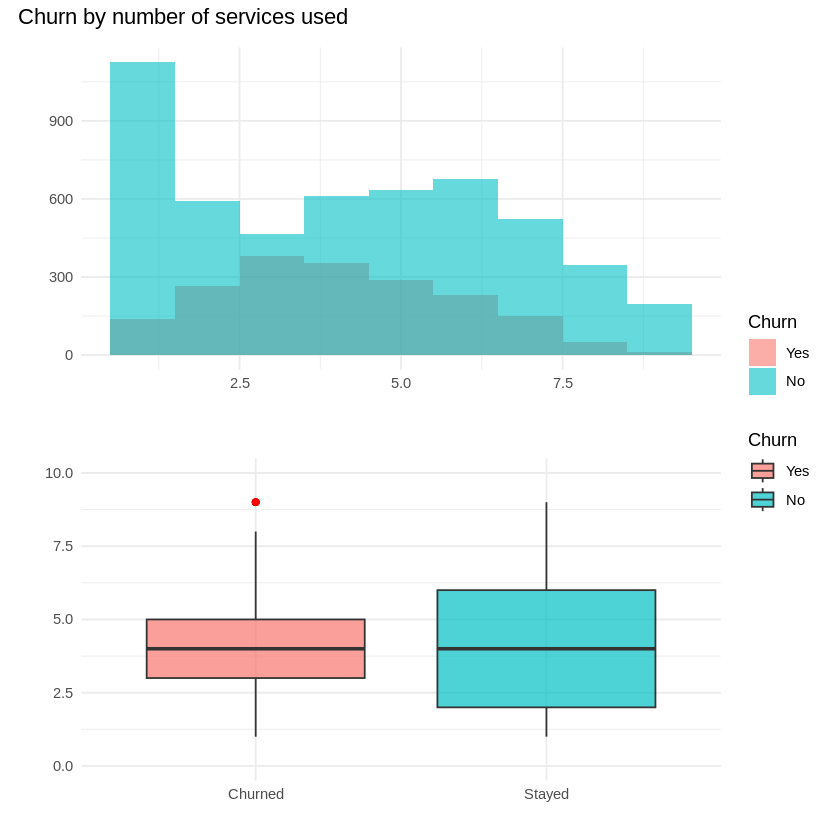

In [ ]:
p5tc1 <- ggplot(data_clean, aes(fill = Churn, x = TelcoServices)) +
  geom_histogram(position = "identity", alpha = 0.6, binwidth = 1) +
  xlab("") + ylab("") + theme_minimal()

p5tc2 <- ggplot(data_clean, aes(x = Churn, y = TelcoServices, fill = Churn)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red") +
  labs(title = "", x = "", y = "") + theme_minimal() +
  scale_x_discrete(labels = c("No" = "Stayed", "Yes" = "Churned")) +
  scale_y_continuous(limits = c(0, 10))

p5tc1 + p5tc2 + plot_annotation(title = "Churn by number of services used") + plot_layout(nrow = 2, ncol = 1, guides = "collect")

In [ ]:
by(data_clean[c("TelcoServices")], data_clean$Churn, summary)

data_clean$Churn: Yes
 TelcoServices  
 Min.   :1.000  
 1st Qu.:3.000  
 Median :4.000  
 Mean   :4.072  
 3rd Qu.:5.000  
 Max.   :9.000  
------------------------------------------------------------ 
data_clean$Churn: No
 TelcoServices  
 Min.   :1.000  
 1st Qu.:2.000  
 Median :4.000  
 Mean   :4.173  
 3rd Qu.:6.000  
 Max.   :9.000  

Next, we will normalize the 3 clustering variables: `tenure`, `MonthlyCharges`, and `TelcoServices`. This process will scale their values to a range of 0 to 1.

In [ ]:
range01 <- function(x){(x-min(x))/(max(x)-min(x))}

data_standardized <- data_clean
data_standardized$tenure <- range01(data_standardized$tenure)
data_standardized$MonthlyCharges <- range01(data_standardized$MonthlyCharges)
data_standardized$TelcoServices <- range01(data_standardized$TelcoServices)

sub_data_standard <- data_standardized %>%
  dplyr::select(tenure, MonthlyCharges, TelcoServices)

summary(sub_data_standard)

     tenure       MonthlyCharges   TelcoServices   
 Min.   :0.0000   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:0.1250   1st Qu.:0.1716   1st Qu.:0.1250  
 Median :0.4028   Median :0.5184   Median :0.3750  
 Mean   :0.4496   Mean   :0.4628   Mean   :0.3933  
 3rd Qu.:0.7639   3rd Qu.:0.7124   3rd Qu.:0.6250  
 Max.   :1.0000   Max.   :1.0000   Max.   :1.0000  

## How many clusters?

Now it’s time to determine how many clusters we should have at the end of our clustering procedure.

In [ ]:
install.packages(c("factoextra", "cluster"), quiet = TRUE)

also installing the dependencies ‘rbibutils’, ‘Deriv’, ‘microbenchmark’, ‘Rdpack’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘lazyeval’, ‘carData’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘crosstalk’, ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘corrplot’, ‘viridis’, ‘car’, ‘DT’, ‘ellipse’, ‘emmeans’, ‘flashClust’, ‘leaps’, ‘multcompView’, ‘scatterplot3d’, ‘ggsci’, ‘cowplot’, ‘ggsignif’, ‘gridExtra’, ‘polynom’, ‘rstatix’, ‘plyr’, ‘abind’, ‘dendextend’, ‘FactoMineR’, ‘ggpubr’, ‘reshape2’, ‘ggrepel’




Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa



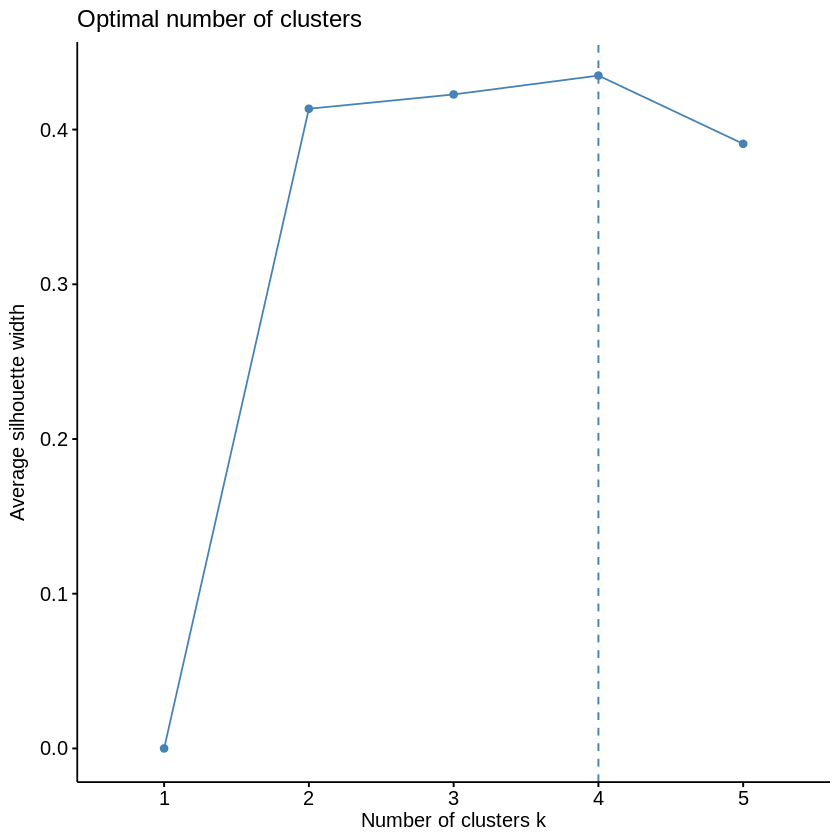

In [ ]:
library(factoextra)
set.seed(42)

# limiting the max number of clusters to 5 because a bigger number would leave us with a less interpretable set of clusters

factoextra::fviz_nbclust(sub_data_standard, kmeans, method = "silhouette", k.max = 5)

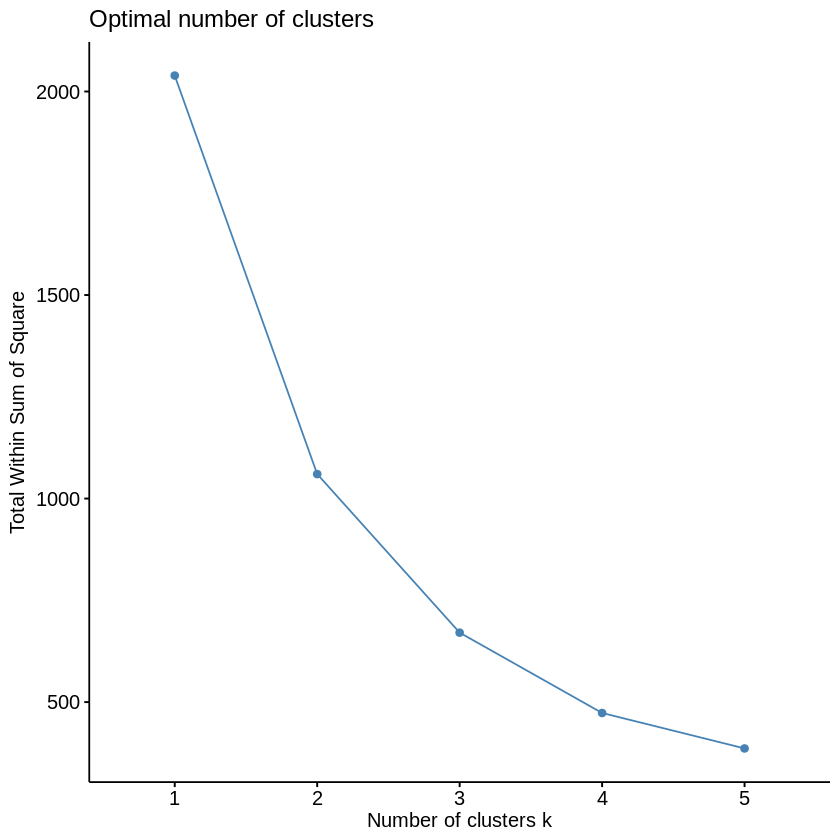

In [ ]:
fviz_nbclust(sub_data_standard, kmeans, method = "wss", k.max = 5)

The silhouette plot suggests that 4 clusters is the optimal choice, while the other plot indicates 3-4 clusters. I tested k-means clustering with both 3 and 4 centers and found that using 3 centers provides more interpretable results.

## K-means clustering

In [ ]:
install.packages(c("MASS", "descr", "caret"), quiet = TRUE)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘pROC’, ‘recipes’




In [ ]:
library(MASS)
library(descr)
library(caret)


Attaching package: ‘MASS’


The following object is masked from ‘package:patchwork’:

    area


The following object is masked from ‘package:dplyr’:

    select


Loading required package: lattice



In [ ]:
set.seed(42)

model_customers <- kmeans(sub_data_standard, centers = 3)

clust_customers <- model_customers$cluster

# adding the cluster id variable we will use later
sub_data_standard <- mutate(sub_data_standard, cluster = clust_customers)
data_standardized <- mutate(data_standardized, cluster = clust_customers)
data_clean <- mutate(data_clean, cluster = clust_customers)
data_full <- mutate(data_full, cluster = clust_customers)

sub_data_standard %>%
  group_by(cluster) %>%
  count()

cluster,n
<int>,<int>
1,2669
2,2026
3,2348


In [ ]:
# making cluster a factor variable
data_full$cluster = as.factor(data_full$cluster)
data_clean$cluster = as.factor(data_clean$cluster)

In [ ]:
# checking if cluster data type is correct
str(data_clean)

'data.frame':	7043 obs. of  21 variables:
 $ gender          : Factor w/ 2 levels "Female","Male": 1 2 2 2 1 1 2 1 1 2 ...
 $ SeniorCitizen   : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ Partner         : Factor w/ 2 levels "No","Yes": 2 1 1 1 1 1 1 1 2 1 ...
 $ Dependents      : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 2 1 1 2 ...
 $ tenure          : int  1 34 2 45 2 8 22 10 28 62 ...
 $ PhoneService    : num  0 1 1 0 1 1 1 0 1 1 ...
 $ MultipleLines   : num  0 0 0 0 0 1 1 0 1 0 ...
 $ InternetService : num  1 1 1 1 1 1 1 1 1 1 ...
 $ OnlineSecurity  : num  0 1 1 1 0 0 0 1 0 1 ...
 $ OnlineBackup    : num  1 0 1 0 0 0 1 0 0 1 ...
 $ DeviceProtection: num  0 1 0 1 0 1 0 0 1 0 ...
 $ TechSupport     : num  0 0 0 1 0 0 0 0 1 0 ...
 $ StreamingTV     : num  0 0 0 0 0 1 1 0 1 0 ...
 $ StreamingMovies : num  0 0 0 0 0 1 0 0 1 0 ...
 $ Contract        : Factor w/ 3 levels "Month-to-month",..: 1 2 1 2 1 1 1 1 1 2 ...
 $ PaperlessBilling: Factor w/ 2 levels "No","Yes": 2 1 2 

In [ ]:
str(data_full)

'data.frame':	7043 obs. of  22 variables:
 $ customerID      : chr  "7590-VHVEG" "5575-GNVDE" "3668-QPYBK" "7795-CFOCW" ...
 $ gender          : Factor w/ 2 levels "Female","Male": 1 2 2 2 1 1 2 1 1 2 ...
 $ SeniorCitizen   : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ Partner         : Factor w/ 2 levels "No","Yes": 2 1 1 1 1 1 1 1 2 1 ...
 $ Dependents      : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 2 1 1 2 ...
 $ tenure          : int  1 34 2 45 2 8 22 10 28 62 ...
 $ PhoneService    : Factor w/ 2 levels "No","Yes": 1 2 2 1 2 2 2 1 2 2 ...
 $ MultipleLines   : Factor w/ 3 levels "No","No phone service",..: 2 1 1 2 1 3 3 2 3 1 ...
 $ InternetService : Factor w/ 3 levels "DSL","Fiber optic",..: 1 1 1 1 2 2 2 1 2 1 ...
 $ OnlineSecurity  : Factor w/ 3 levels "No","No internet service",..: 1 3 3 3 1 1 1 3 1 3 ...
 $ OnlineBackup    : Factor w/ 3 levels "No","No internet service",..: 3 1 3 1 1 1 3 1 1 3 ...
 $ DeviceProtection: Factor w/ 3 levels "No","No internet service

## Cluster description

### Numerical variables

We will first inspect the clusters and describe them based on the 3 clustering variables: `tenure`, `MonthlyCharges`, and `TelcoServices`. The other numerical variable, `TotalCharges`, was excluded from the clustering procedure due to its high correlation with tenure and `MonthlyCharges`. However, we will now reintroduce it to enhance our cluster descriptions.

In [ ]:
by(data_clean[c("TelcoServices", "MonthlyCharges", "tenure")], data_clean$cluster, summary)

data_clean$cluster: 1
 TelcoServices   MonthlyCharges       tenure     
 Min.   :2.000   Min.   : 35.90   Min.   : 0.00  
 1st Qu.:3.000   1st Qu.: 59.45   1st Qu.: 3.00  
 Median :4.000   Median : 74.90   Median :10.00  
 Mean   :4.043   Mean   : 73.49   Mean   :13.05  
 3rd Qu.:5.000   3rd Qu.: 85.75   3rd Qu.:21.00  
 Max.   :9.000   Max.   :112.95   Max.   :46.00  
------------------------------------------------------------ 
data_clean$cluster: 2
 TelcoServices   MonthlyCharges      tenure     
 Min.   :1.000   Min.   :18.25   Min.   : 0.00  
 1st Qu.:1.000   1st Qu.:19.85   1st Qu.: 8.00  
 Median :1.000   Median :20.50   Median :25.00  
 Mean   :1.524   Mean   :25.19   Mean   :29.22  
 3rd Qu.:2.000   3rd Qu.:25.45   3rd Qu.:49.00  
 Max.   :4.000   Max.   :71.05   Max.   :72.00  
------------------------------------------------------------ 
data_clean$cluster: 3
 TelcoServices   MonthlyCharges       tenure     
 Min.   :2.000   Min.   : 38.50   Min.   :20.00  
 1st Qu.:6.000   

In [ ]:
by(data_full$TotalCharges, data_full$cluster, summary)

data_full$cluster: 1
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   35.9   217.4   759.5   979.4  1581.2  3548.3 
------------------------------------------------------------ 
data_full$cluster: 2
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   18.8   167.6   565.9   755.6  1230.5  3842.6 
------------------------------------------------------------ 
data_full$cluster: 3
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1838    3784    4918    5073    6287    8685 

Cluster 1:

- `TelcoServices`:  the median and the mean is 4 services, and the central 50% of customers have used between 3 and 5 services over their tenure. The overall range is 2-9 services.

- `MonthlyCharges`: the median is 75 USD, the mean is 73 USD, and the central 50% of customers have paid between 59 USD and 86 USD over their tenure. The overall range is 36-113 USD.

- `tenure`: the median is 10 months, the mean is 13 months, and the central 50% of customers have been with the company between 3 and 21 months. The overall range is 0-46 months.

- `TotalCharges`: the median is 760 USD, the mean is 979 USD, and the central 50% of customers have paid between 217 USD and 1581 USD over their tenure. The overall range is 36-3548 USD.

Cluster 2:

- `TelcoServices`: the median is 1 service, the mean is 2 services, and the central 50% of customers have used between 1 and 2 services over their tenure. The overall range is 1-4 services.

- `MonthlyCharges`:  the median is 21 USD, the mean is 25 USD, and the central 50% of customers have paid between 20 USD and 25 USD over their tenure. The overall range is 18-71 USD.

- `tenure`: the median is 25 months, the mean is 29 months, and the central 50% of customers have been with the company between 8 and 49 months. The overall range is 0-72 months.

- `TotalCharges`: the median is 566 USD, the mean is 756 USD, and the central 50% of customers have paid between 168 USD and 1230 USD over their tenure. The overall range is 19-3853 USD.

Cluster 3:

- `TelcoServices`: the median and the mean is 7 services, and the central 50% of customers have used between 6 and 8 services over their tenure. The overall range is 2-9 services.

- `MonthlyCharges`: the median is 92 USD, the mean is 89 USD, and the central 50% of customers have paid between 77 USD and 104 USD over their tenure. The overall range is 39-119 USD.

- `tenure`: the median is 60 months, the mean is 57 months, and the central 50% of customers have been with the company between 48 and 69 months. The overall range is 20-72 months.

- `TotalCharges`: the median is 4918 USD, the mean is 5073 USD, and the central 50% of customers have paid between 3784 USD and 6287 USD over their tenure. The overall range is 1838-8685 USD.

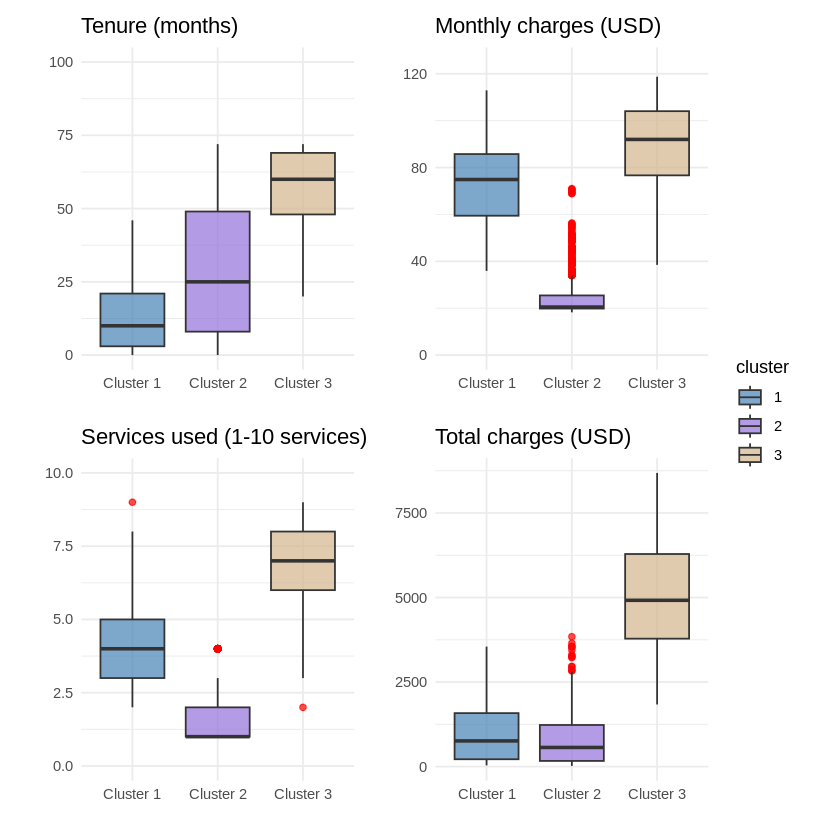

In [ ]:
pclust <- ggplot(data_clean, aes(x = cluster, y = TelcoServices, fill = cluster)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red") +
  labs(title = "Services used (1-9 services)", x = "", y = "") + theme_minimal() +
  scale_x_discrete(labels = c("1" = "Cluster 1", "2" = "Cluster 2", "3" = "Cluster 3")) +
  scale_y_continuous(limits = c(0, 10)) +
  scale_fill_manual(values = c("steelblue", "mediumpurple", "tan"))

pclust0 <- ggplot(data_clean, aes(x = cluster, y = MonthlyCharges, fill = cluster)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red") +
  labs(title = "Monthly charges (USD)", x = "", y = "") + theme_minimal() +
  scale_x_discrete(labels = c("1" = "Cluster 1", "2" = "Cluster 2", "3" = "Cluster 3")) +
  scale_y_continuous(limits = c(0, 125)) +
  scale_fill_manual(values = c("steelblue", "mediumpurple", "tan"))

pclust1 <- ggplot(data_clean, aes(x = cluster, y = tenure, fill = cluster)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red") +
  labs(title = "Tenure (months)", x = "", y = "") + theme_minimal() +
  scale_x_discrete(labels = c("1" = "Cluster 1", "2" = "Cluster 2", "3" = "Cluster 3")) +
  scale_y_continuous(limits = c(0, 100)) +
  scale_fill_manual(values = c("steelblue", "mediumpurple", "tan"))

pclust2 <- ggplot(data_full, aes(x = cluster, y = TotalCharges, fill = cluster)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red") +
  labs(title = "Total charges (USD)", x = "", y = "") + theme_minimal() +
  scale_x_discrete(labels = c("1" = "Cluster 1", "2" = "Cluster 2", "3" = "Cluster 3")) +
  scale_fill_manual(values = c("steelblue", "mediumpurple", "tan"))

pclust1 + pclust0 + pclust + pclust2 + plot_layout(nrow = 2, ncol = 2, guides = "collect")

For reference, the overall dataset ranges were 0-72 months (6 years) for `tenure`, 18-119 USD for `MonthlyCharges`, and 1-9 services for `TelcoServices`. The overall range for `TotalCharges` was 19-8685 USD.

**Cluster 1**:
- short tenure (median is 10 months),
- 4 services used,
- moderate monthly charges (median is 75 USD).

*(and as a result low total charges, median is 760 USD)*

**Cluster 2**:
- moderate tenure (median is 25 months),
- 1-2 services used,
- low monthly charges (median is 21 USD).

*(and as a result low total charges, median is 566 USD)*

**Cluster 3**:
- long tenure (median is 60 months),
- more than half of the services used (median is 7 services),
- high monthly charges (median is 92 USD).

*(and as a result high total charges, median is 4918 USD)*

### Categorical variables

Next, we will examine churn rates and the distributions of other categorical variables for each cluster.

In [ ]:
by(data_clean[c("Churn", "gender", "SeniorCitizen", "Partner", "Dependents", "Contract", "PaperlessBilling", "PaymentMethod")],
   data_clean$cluster,
   function(x) {
     lapply(x, function(col) {
       tbl <- table(col)
       data.frame(
         Category = names(tbl),
         n = as.numeric(tbl),
         Proportion = sprintf("%.0f%%", prop.table(tbl) * 100)
       )
     })
   })

data_clean$cluster: 1
$Churn
  Category    n Proportion
1      Yes 1259        47%
2       No 1410        53%

$gender
  Category    n Proportion
1   Female 1330        50%
2     Male 1339        50%

$SeniorCitizen
  Category    n Proportion
1       No 2136        80%
2      Yes  533        20%

$Partner
  Category    n Proportion
1       No 1784        67%
2      Yes  885        33%

$Dependents
  Category    n Proportion
1       No 2137        80%
2      Yes  532        20%

$Contract
        Category    n Proportion
1 Month-to-month 2345        88%
2       One year  268        10%
3       Two year   56         2%

$PaperlessBilling
  Category    n Proportion
1       No  830        31%
2      Yes 1839        69%

$PaymentMethod
                   Category    n Proportion
1 Bank transfer (automatic)  378        14%
2   Credit card (automatic)  377        14%
3          Electronic check 1377        52%
4              Mailed check  537        20%

--------------------------------------

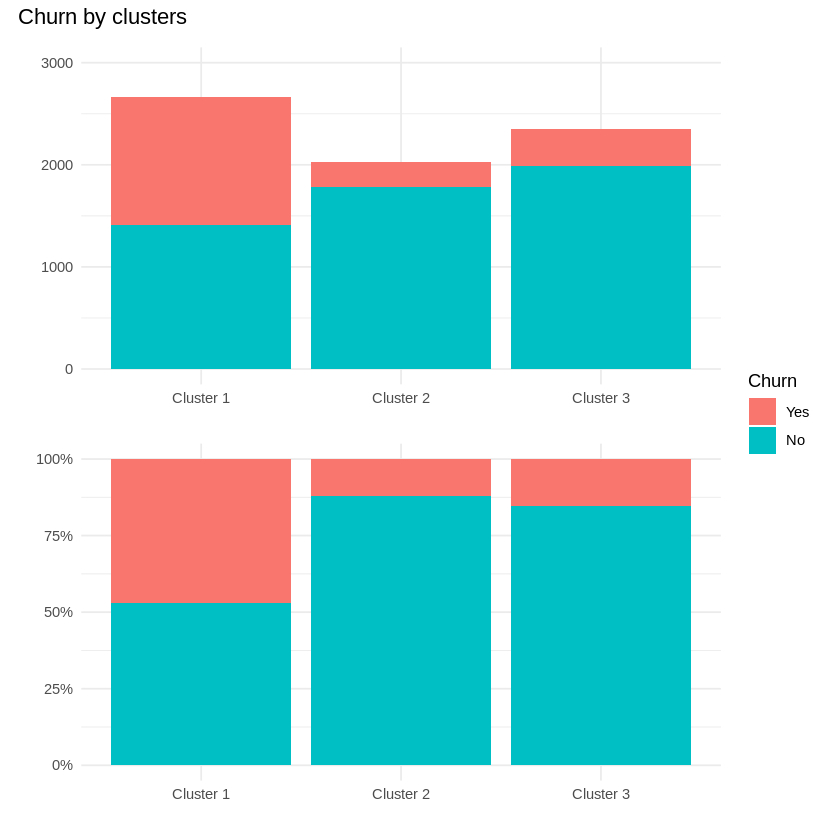

In [ ]:
cl_count <- ggplot(data_clean, aes(as.factor(cluster), fill = Churn)) +
  geom_bar() + scale_y_continuous(limits = c(0, 3000)) + ylab("") + xlab("") +
  theme_minimal() + scale_x_discrete(labels = c("1" = "Cluster 1", "2" = "Cluster 2", "3" = "Cluster 3"))

cl_count2 <- ggplot(data_clean, aes(as.factor(cluster), fill = Churn)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + ylab("") + xlab("") +
  theme_minimal() + scale_x_discrete(labels = c("1" = "Cluster 1", "2" = "Cluster 2", "3" = "Cluster 3"))

cl_count + cl_count2 + plot_annotation(title = "Churn by clusters") + plot_layout(nrow = 2, ncol = 1, guides = "collect")

**Cluster 1** (n=2669):
- churn is 47% (highest rate)
- 20% are senior citizens
- 67% do not have a partner (highest share)
- 80% do not have dependents (highest share)
- gender 50%/50%
- contract type:
  - 88% month-to-month (highest share)
  - 10% one year
  - 2% two year
- 69% have paperless billing
- payment method:
  - 14% bank transfer (automatic)
  - 14% credit card (automatic)
  - 52% electronic check (highest share)
  - 20% mailed check

**Cluster 2** (n=2026):
- churn is 12%
- 6% are senior citizens (lowest share)
- 53% do not have a partner
- 61% do not have dependents
- 49% female, 51% male
- contract type:
  - 44% month-to-month
  - 23% one year
  - 34% two year
- 35% have paperless billing (lowest share)
- payment method:
  - 21% bank transfer (automatic)
  - 21% credit card (automatic)
  - 14% electronic check
  - 44% mailed check (highest share)

**Cluster 3** (n=2348):
- churn is 15%
- 21% are senior citizens
- 33% do not have a partner (lowest share)
- 66% do not have dependents
- gender 50%/50%
- contract type:
  - 27% month-to-month
  - 32% one year (highest share)
  - 41% two year (highest share)
- 69% have paperless billing
- payment method:
  - 31% bank transfer (automatic)
  - 30% credit card (automatic)
  - 30% electronic check
  - 8% mailed check

**Cluster 1** have the highest churn rate (47%) and we will explore this segment further.

# Churn prediction

## Logistic regression: statistics

### Data preparation

No we are creating a separate dataset for Cluster 1. The `cluster` and `TelcoServices` variables can be removed as they are no longer needed. We also replace the recoded `InternetService` variable with its original version containing 3 categories (DSL, Fiber optic, and No internet service), each representing a customer's internet service provider. This will be helpful later in our regression analysis.

In [ ]:
data_clean$InternetService <- data_full$InternetService

cluster_1_data <- data_clean %>%
  filter(cluster == "1")

cluster_1_data <- cluster_1_data[-c(20, 21)]

In [ ]:
str(cluster_1_data)

'data.frame':	2669 obs. of  19 variables:
 $ gender          : Factor w/ 2 levels "Female","Male": 2 2 1 1 2 2 1 1 2 1 ...
 $ SeniorCitizen   : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 1 2 1 ...
 $ Partner         : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 2 2 1 1 1 ...
 $ Dependents      : Factor w/ 2 levels "No","Yes": 1 1 1 1 2 2 2 1 1 1 ...
 $ tenure          : int  34 2 2 8 22 13 10 21 1 30 ...
 $ PhoneService    : num  1 1 1 1 1 1 1 1 0 1 ...
 $ MultipleLines   : num  0 0 0 1 1 0 0 0 0 0 ...
 $ InternetService : Factor w/ 3 levels "DSL","Fiber optic",..: 1 1 2 2 2 1 1 2 1 1 ...
 $ OnlineSecurity  : num  1 1 0 0 0 1 0 0 0 1 ...
 $ OnlineBackup    : num  0 1 0 0 1 0 0 1 0 1 ...
 $ DeviceProtection: num  1 0 0 1 0 0 1 1 1 0 ...
 $ TechSupport     : num  0 0 0 0 0 0 1 0 0 0 ...
 $ StreamingTV     : num  0 0 0 1 1 0 0 0 0 0 ...
 $ StreamingMovies : num  0 0 0 1 0 0 0 1 1 0 ...
 $ Contract        : Factor w/ 3 levels "Month-to-month",..: 2 1 1 1 1 1 1 1 1 1 ...
 $ PaperlessBilling:

In [ ]:
summary(cluster_1_data)

    gender     SeniorCitizen Partner    Dependents     tenure     
 Female:1330   No :2136      No :1784   No :2137   Min.   : 0.00  
 Male  :1339   Yes: 533      Yes: 885   Yes: 532   1st Qu.: 3.00  
                                                   Median :10.00  
                                                   Mean   :13.05  
                                                   3rd Qu.:21.00  
                                                   Max.   :46.00  
  PhoneService    MultipleLines       InternetService OnlineSecurity  
 Min.   :0.0000   Min.   :0.0000   DSL        :1020   Min.   :0.0000  
 1st Qu.:1.0000   1st Qu.:0.0000   Fiber optic:1649   1st Qu.:0.0000  
 Median :1.0000   Median :0.0000   No         :   0   Median :0.0000  
 Mean   :0.9464   Mean   :0.3706                      Mean   :0.2282  
 3rd Qu.:1.0000   3rd Qu.:1.0000                      3rd Qu.:0.0000  
 Max.   :1.0000   Max.   :1.0000                      Max.   :1.0000  
  OnlineBackup    DeviceProtection

Before running logistic regression, we will make sure that all variable types are correct.

In [ ]:
cluster_1_data[c(6, 7)] <- lapply(cluster_1_data[c(6, 7)], as.factor)
cluster_1_data[c(9:14)] <- lapply(cluster_1_data[c(9:14)], as.factor)

# there are no customers without InternetService in Cluster 1, so we will remove this level
cluster_1_data$InternetService <- droplevels(cluster_1_data$InternetService)
str(cluster_1_data)

'data.frame':	2669 obs. of  19 variables:
 $ gender          : Factor w/ 2 levels "Female","Male": 2 2 1 1 2 2 1 1 2 1 ...
 $ SeniorCitizen   : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 1 2 1 ...
 $ Partner         : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 2 2 1 1 1 ...
 $ Dependents      : Factor w/ 2 levels "No","Yes": 1 1 1 1 2 2 2 1 1 1 ...
 $ tenure          : int  34 2 2 8 22 13 10 21 1 30 ...
 $ PhoneService    : Factor w/ 2 levels "0","1": 2 2 2 2 2 2 2 2 1 2 ...
 $ MultipleLines   : Factor w/ 2 levels "0","1": 1 1 1 2 2 1 1 1 1 1 ...
 $ InternetService : Factor w/ 2 levels "DSL","Fiber optic": 1 1 2 2 2 1 1 2 1 1 ...
 $ OnlineSecurity  : Factor w/ 2 levels "0","1": 2 2 1 1 1 2 1 1 1 2 ...
 $ OnlineBackup    : Factor w/ 2 levels "0","1": 1 2 1 1 2 1 1 2 1 2 ...
 $ DeviceProtection: Factor w/ 2 levels "0","1": 2 1 1 2 1 1 2 2 2 1 ...
 $ TechSupport     : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 2 1 1 1 ...
 $ StreamingTV     : Factor w/ 2 levels "0","1": 1 1 1 2 2 1 1 1 1 1 .

In [ ]:
cluster_1_data <- cluster_1_data %>%
  mutate(
    PhoneService = recode(PhoneService, "0" = "No", "1" = "Yes"),
    MultipleLines = recode(MultipleLines, "0" = "No", "1" = "Yes"),
    OnlineSecurity = recode(OnlineSecurity, "0" = "No", "1" = "Yes"),
    OnlineBackup = recode(OnlineBackup, "0" = "No", "1" = "Yes"),
    DeviceProtection = recode(DeviceProtection, "0" = "No", "1" = "Yes"),
    TechSupport = recode(TechSupport, "0" = "No", "1" = "Yes"),
    StreamingTV = recode(StreamingTV, "0" = "No", "1" = "Yes"),
    StreamingMovies = recode(StreamingMovies, "0" = "No", "1" = "Yes")
  )

In [ ]:
str(cluster_1_data)

'data.frame':	2669 obs. of  19 variables:
 $ gender          : Factor w/ 2 levels "Female","Male": 2 2 1 1 2 2 1 1 2 1 ...
 $ SeniorCitizen   : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 1 1 2 1 ...
 $ Partner         : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 2 2 1 1 1 ...
 $ Dependents      : Factor w/ 2 levels "No","Yes": 1 1 1 1 2 2 2 1 1 1 ...
 $ tenure          : int  34 2 2 8 22 13 10 21 1 30 ...
 $ PhoneService    : Factor w/ 2 levels "No","Yes": 2 2 2 2 2 2 2 2 1 2 ...
 $ MultipleLines   : Factor w/ 2 levels "No","Yes": 1 1 1 2 2 1 1 1 1 1 ...
 $ InternetService : Factor w/ 2 levels "DSL","Fiber optic": 1 1 2 2 2 1 1 2 1 1 ...
 $ OnlineSecurity  : Factor w/ 2 levels "No","Yes": 2 2 1 1 1 2 1 1 1 2 ...
 $ OnlineBackup    : Factor w/ 2 levels "No","Yes": 1 2 1 1 2 1 1 2 1 2 ...
 $ DeviceProtection: Factor w/ 2 levels "No","Yes": 2 1 1 2 1 1 2 2 2 1 ...
 $ TechSupport     : Factor w/ 2 levels "No","Yes": 1 1 1 1 1 1 2 1 1 1 ...
 $ StreamingTV     : Factor w/ 2 levels "No","Yes": 

### Binary logistic regression

Setting our reference class to “No”.

In [ ]:
cluster_1_data$Churn <- relevel(cluster_1_data$Churn, ref = "No")

In [ ]:
cluster_1_data$SeniorCitizen <- relevel(factor(cluster_1_data$SeniorCitizen), ref = "No")
cluster_1_data$Partner <- relevel(factor(cluster_1_data$Partner), ref = "No")
cluster_1_data$Dependents <- relevel(factor(cluster_1_data$Dependents), ref = "No")
cluster_1_data$PhoneService <- relevel(factor(cluster_1_data$PhoneService), ref = "No")
cluster_1_data$MultipleLines <- relevel(factor(cluster_1_data$MultipleLines), ref = "No")
cluster_1_data$OnlineSecurity <- relevel(factor(cluster_1_data$OnlineSecurity), ref = "No")
cluster_1_data$OnlineBackup <- relevel(factor(cluster_1_data$OnlineBackup), ref = "No")
cluster_1_data$DeviceProtection <- relevel(factor(cluster_1_data$DeviceProtection), ref = "No")
cluster_1_data$TechSupport <- relevel(factor(cluster_1_data$TechSupport), ref = "No")
cluster_1_data$StreamingTV <- relevel(factor(cluster_1_data$StreamingTV), ref = "No")
cluster_1_data$StreamingMovies <- relevel(factor(cluster_1_data$StreamingMovies), ref = "No")
cluster_1_data$PaperlessBilling <- relevel(factor(cluster_1_data$PaperlessBilling), ref = "No")

In this section we are using all variables as predictors of churn.

In [ ]:
logitModelFull1 <- glm(Churn ~ gender + SeniorCitizen + Partner + Dependents + tenure + PhoneService + MultipleLines + InternetService + TechSupport + OnlineBackup + OnlineSecurity + DeviceProtection + StreamingTV + StreamingMovies + Contract + PaperlessBilling + PaymentMethod + MonthlyCharges, family = "binomial", data = cluster_1_data)

summary(logitModelFull1)


Call:
glm(formula = Churn ~ gender + SeniorCitizen + Partner + Dependents + 
    tenure + PhoneService + MultipleLines + InternetService + 
    TechSupport + OnlineBackup + OnlineSecurity + DeviceProtection + 
    StreamingTV + StreamingMovies + Contract + PaperlessBilling + 
    PaymentMethod + MonthlyCharges, family = "binomial", data = cluster_1_data)

Coefficients:
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                           1.090852   1.136574   0.960  0.33717    
genderMale                           -0.111445   0.088092  -1.265  0.20584    
SeniorCitizenYes                      0.156241   0.114295   1.367  0.17162    
PartnerYes                           -0.003905   0.107543  -0.036  0.97104    
DependentsYes                         0.022858   0.130561   0.175  0.86102    
tenure                               -0.050589   0.004886 -10.355  < 2e-16 ***
PhoneServiceYes                       0.194436   0.914426   0.213  0.83161

In [ ]:
LogRegR2(logitModelFull1)

Chi2                 647.2327 
Df                   21 
Sig.                 0 
Cox and Snell Index  0.2153363 
Nagelkerke Index     0.2874224 
McFadden's R2        0.1753319 

In [ ]:
coefsexp <- round(((exp(logitModelFull1$coefficients)-1)*100))
coefsexp

(Intercept)                           genderMale 
                                 198                                  -11 
                    SeniorCitizenYes                           PartnerYes 
                                  17                                    0 
                       DependentsYes                               tenure 
                                   2                                   -5 
                     PhoneServiceYes                     MultipleLinesYes 
                                  21                                   69 
          InternetServiceFiber optic                       TechSupportYes 
                                 601                                  -11 
                     OnlineBackupYes                    OnlineSecurityYes 
                                  -1                                  -18 
                 DeviceProtectionYes                       StreamingTVYes 
                                  19                                   74 
                  StreamingMoviesYes                     ContractOne year 
                                  82                                  -59 
                    ContractTwo year                  PaperlessBillingYes 
                                 -94                                   50 
PaymentMethodCredit card (automatic)        PaymentMethodElectronic check 
                                  -4                                   39 
           PaymentMethodMailed check                       MonthlyCharges 
                                  10                                   -4

The following variables did have a statistically significant influence on customer churn in **Cluster 1** (p-value < 0.05).

Coefficient interpretations:

- `tenure`: for each additional month a customer stays with the company, the odds of churning **decrease by 5%**.

- `MultipleLines` (Yes): the odds of churning for customers with multiple lines are **69% higher** as compared to customers without it.

- `Contract` (One-year): the odds of churning for customers with a one-year contract are **59% lower** as compared to customers with a month-to-month contract.

- `Contract` (Two-year): the odds of churning for customers with a two-year contract are **94% lower** as compared to customers with a month-to-month contract.

- `PaperlessBilling` (Yes): the odds of churning for customers with paperless billing are **50% higher** as compared to customers with paper billing.

- `PaymentMethod` (Electronic check): the odds of churning for customers with electronic check as their payment method are **39% higher** as compared to customers with the bank transfer (automatic) payment method.

Let's visualize churn for the statistically significant variables in **Cluster 1**.

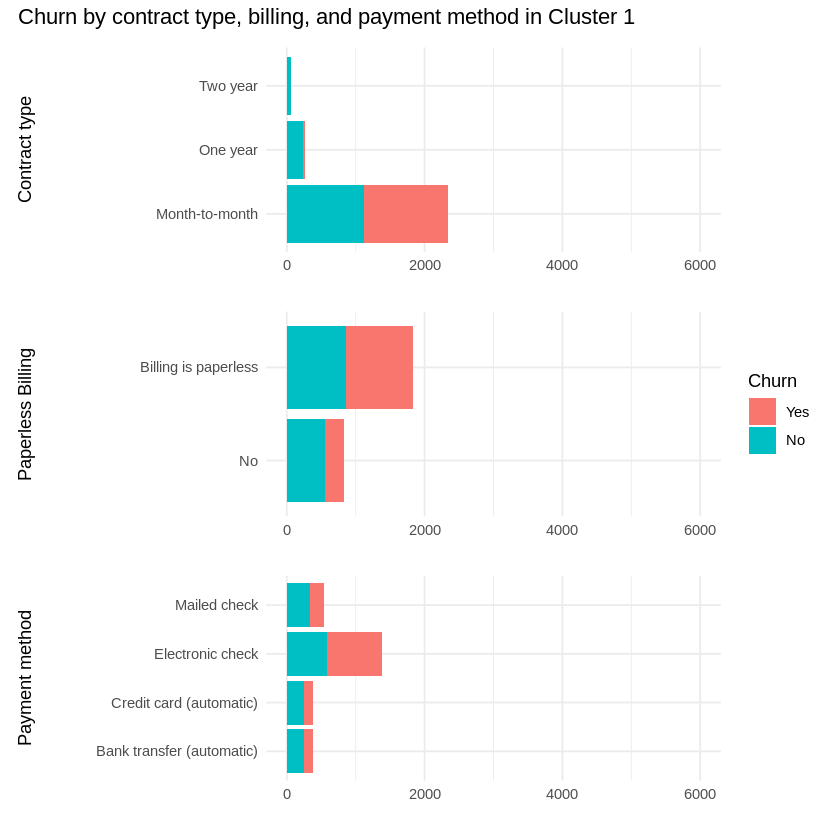

In [ ]:
cluster_1_data$Churn <- relevel(cluster_1_data$Churn, ref = "Yes")

p20 <- ggplot(cluster_1_data, aes(fill = Churn, x = Contract)) +
  geom_bar(position = "stack") + coord_flip() + ylab(" ") + xlab("Contract type") + scale_y_continuous(limits = c(0, 6000))  + theme_minimal()

p21 <- ggplot(cluster_1_data, aes(fill = Churn, x = PaperlessBilling)) +
  geom_bar(position = "stack") + coord_flip() + xlab("Paperless Billing") + ylab(" ") + scale_y_continuous(limits = c(0, 6000)) + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No", "Yes" = "Billing is paperless"))

p22 <- ggplot(cluster_1_data, aes(fill = Churn, x = PaymentMethod)) +
  geom_bar(position = "stack") + coord_flip() + ylab(" ") + xlab("Payment method") + scale_y_continuous(limits = c(0, 6000)) + theme_minimal()

p20 + p21 + p22 + plot_annotation(title = "Churn by contract type, billing, and payment method in Cluster 1") + plot_layout(nrow = 3, guides = "collect")

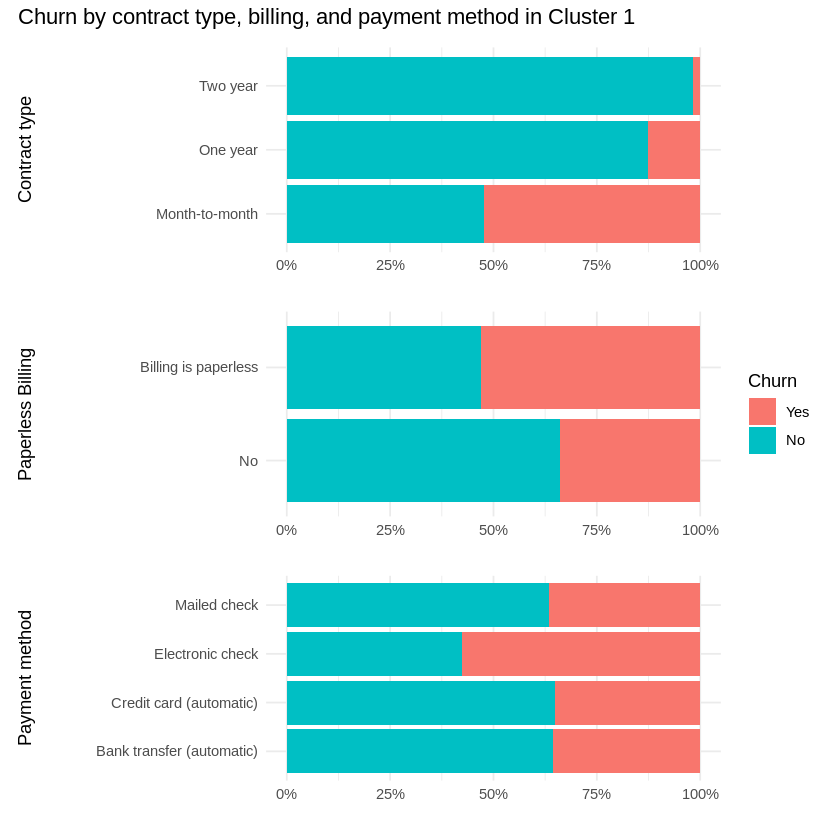

In [ ]:
p20 <- ggplot(cluster_1_data, aes(fill = Churn, x = Contract)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + coord_flip() + ylab(" ") + xlab("Contract type") +
  theme_minimal()

p21 <- ggplot(cluster_1_data, aes(fill = Churn, x = PaperlessBilling)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + coord_flip() + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No", "Yes" = "Billing is paperless")) + xlab("Paperless Billing") + ylab("")

p22 <- ggplot(cluster_1_data, aes(fill = Churn, x = PaymentMethod)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + coord_flip() + ylab(" ") + xlab("Payment method") +
  theme_minimal()

p20 + p21 + p22 + plot_annotation(title = "Churn by contract type, billing, and payment method in Cluster 1") + plot_layout(nrow = 3, guides = "collect")

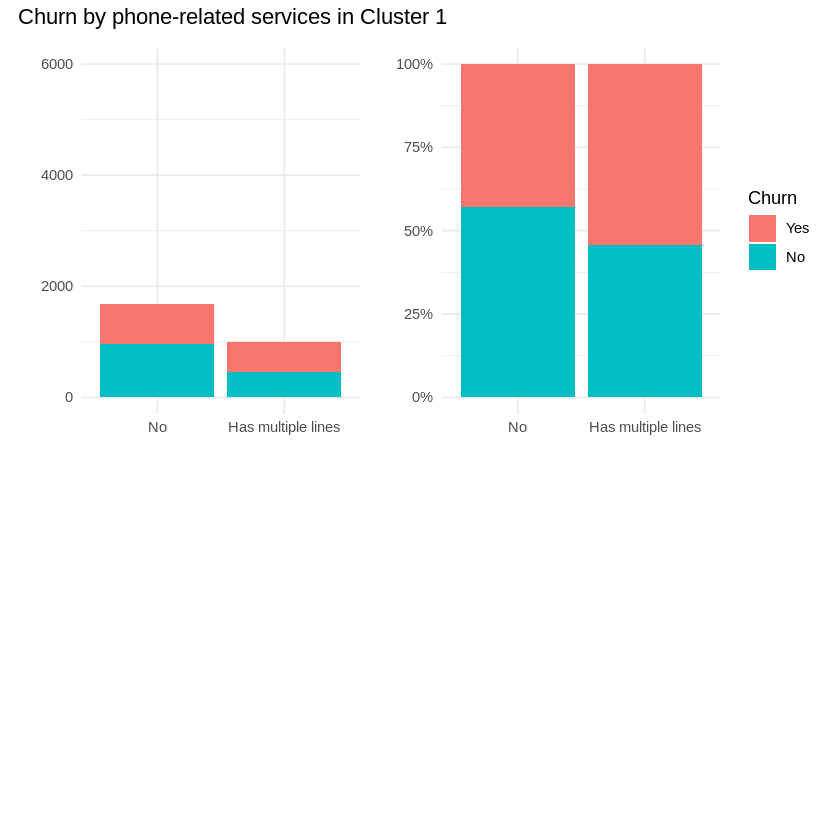

In [ ]:
p23 <- ggplot(cluster_1_data, aes(fill = Churn, x = MultipleLines)) +
  geom_bar(position = "stack") + ylab("") + xlab("") + scale_y_continuous(limits = c(0, 6000)) + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No", "Yes" = "Has multiple lines"))

p24 <- ggplot(cluster_1_data, aes(fill = Churn, x = MultipleLines)) +
  geom_bar(position = "fill") + scale_y_continuous(labels = scales::percent) + ylab("") + xlab("") + theme_minimal() +
  scale_x_discrete(labels = c("No" = "No", "Yes" = "Has multiple lines"))

p23 + p24 + plot_annotation(title = "Churn by phone-related services in Cluster 1") + plot_layout(nrow = 2, ncol = 2, guides = "collect")

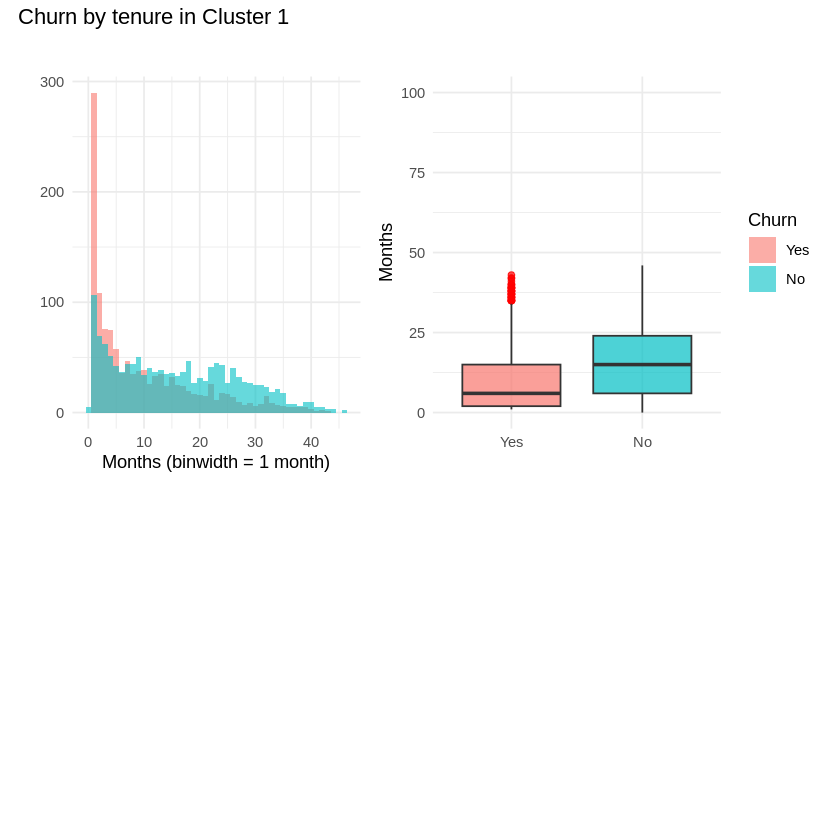

In [ ]:
p25 <- ggplot(cluster_1_data, aes(fill = Churn, x = tenure)) +
  geom_histogram(position = "identity", alpha = 0.6, binwidth = 1) + xlab("Months (binwidth = 1 month)") + ylab("") +
  theme_minimal()

p26 <- ggplot(cluster_1_data, aes(x = Churn, y = tenure, fill = Churn)) +
  geom_boxplot(alpha = 0.7, outlier.color = "red") +
  labs(title = "", x = "", y = "Months") + theme_minimal() +
  scale_y_continuous(limits = c(0, 100)) + theme(legend.position = "none")

p25 + p26 + plot_annotation(title = "Churn by tenure in Cluster 1") + plot_layout(nrow = 2, ncol = 2, guides = "collect")

Recommendations based on EDA and logistic regression results for churn mitigation in Cluster 1:

- Focus retention efforts on newer customers and those with month-to-month contracts, as they show the highest churn risk;


- Investigate sources of dissatisfaction with the multiple line service;


- Investigate churn drivers in digital channels, as paperless billing and the electronic check payment method are significant predictors.

## Logistic regression: ML

### Tailoring the model for classification

Next, we are using the stepAIC() function to determine the model with an optimal set of independent variables. This model will be later used to make predictions.

In [ ]:
logitModelNew1 <- stepAIC(logitModelFull1, trace = 0)
summary(logitModelNew1)


Call:
glm(formula = Churn ~ SeniorCitizen + tenure + MultipleLines + 
    InternetService + OnlineSecurity + StreamingTV + StreamingMovies + 
    Contract + PaperlessBilling + PaymentMethod + MonthlyCharges, 
    family = "binomial", data = cluster_1_data)

Coefficients:
                                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)                          -0.933031   0.435572  -2.142 0.032187 *  
SeniorCitizenYes                     -0.163356   0.111553  -1.464 0.143090    
tenure                                0.051003   0.004761  10.712  < 2e-16 ***
MultipleLinesYes                     -0.498268   0.107457  -4.637 3.54e-06 ***
InternetServiceFiber optic           -1.820585   0.252879  -7.199 6.05e-13 ***
OnlineSecurityYes                     0.230204   0.123522   1.864 0.062369 .  
StreamingTVYes                       -0.492135   0.127745  -3.852 0.000117 ***
StreamingMoviesYes                   -0.537308   0.126574  -4.245 2.19e-05 ***
ContractOne year

### Model fit assessment

Our model’s Pseudo R-squared (McFadden’s R2) can be interpreted as good fit since the value is around 0.2.

In [ ]:
LogRegR2(logitModelNew1)

Chi2                 642.1987 
Df                   14 
Sig.                 0 
Cox and Snell Index  0.213855 
Nagelkerke Index     0.2854452 
McFadden's R2        0.1739682 

### Prediction

Next, we will split the data into train and test datasets, fit a logistic regression model and evaluate its performance.

In [ ]:
cluster_1_data$Churn <- relevel(cluster_1_data$Churn, ref = "No")

In [ ]:
set.seed(42)

cluster_1_data$isTrain <- rbinom(nrow(cluster_1_data), 1, 0.80)
train <- subset(cluster_1_data, cluster_1_data$isTrain == 1)
test <- subset(cluster_1_data, cluster_1_data$isTrain == 0)

In [ ]:
# checking distributions
summary(test)

    gender    SeniorCitizen Partner   Dependents     tenure      PhoneService
 Female:268   No :440       No :362   No :431    Min.   : 1.00   No : 27     
 Male  :275   Yes:103       Yes:181   Yes:112    1st Qu.: 4.00   Yes:516     
                                                 Median :11.00               
                                                 Mean   :13.57               
                                                 3rd Qu.:22.50               
                                                 Max.   :46.00               
 MultipleLines    InternetService OnlineSecurity OnlineBackup DeviceProtection
 No :337       DSL        :195    No :412        No :404      No :408         
 Yes:206       Fiber optic:348    Yes:131        Yes:139      Yes:135         
                                                                              
                                                                              
                                                           

In [ ]:
summary(train)

    gender     SeniorCitizen Partner    Dependents     tenure      PhoneService
 Female:1062   No :1696      No :1422   No :1706   Min.   : 0.00   No : 116    
 Male  :1064   Yes: 430      Yes: 704   Yes: 420   1st Qu.: 3.00   Yes:2010    
                                                   Median :10.00               
                                                   Mean   :12.91               
                                                   3rd Qu.:21.00               
                                                   Max.   :46.00               
 MultipleLines    InternetService OnlineSecurity OnlineBackup DeviceProtection
 No :1343      DSL        : 825   No :1648       No :1540     No :1538        
 Yes: 783      Fiber optic:1301   Yes: 478       Yes: 586     Yes: 588        
                                                                              
                                                                              
                                             

In [ ]:
logitTrainNew <- glm(Churn ~ SeniorCitizen + tenure + MultipleLines + InternetService + OnlineSecurity + StreamingTV + StreamingMovies + Contract + PaperlessBilling + PaymentMethod + MonthlyCharges, family = "binomial", data = train[-20])

In [ ]:
train$pred <- predict(logitTrainNew, train[-20], type = 'response')
train$pred <- ifelse(train$pred > 0.5, "Yes", "No")

test$pred <- predict(logitTrainNew, type = 'response', newdata = test[-c(19, 20)])
test$pred <- ifelse(test$pred > 0.5, "Yes", "No")

In [ ]:
confusionMatrix(as.factor(train$pred), as.factor(train$Churn), positive = "Yes")

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  773 301
       Yes 348 704
                                          
               Accuracy : 0.6947          
                 95% CI : (0.6747, 0.7143)
    No Information Rate : 0.5273          
    P-Value [Acc > NIR] : < 2e-16         
                                          
                  Kappa : 0.3891          
                                          
 Mcnemar's Test P-Value : 0.07097         
                                          
            Sensitivity : 0.7005          
            Specificity : 0.6896          
         Pos Pred Value : 0.6692          
         Neg Pred Value : 0.7197          
             Prevalence : 0.4727          
         Detection Rate : 0.3311          
   Detection Prevalence : 0.4948          
      Balanced Accuracy : 0.6950          
                                          
       'Positive' Class : Yes             
                              

For train data, confusion matrix indicated that sensitivity = 0.7 and specificity = 0.69.

Accuracy is 0.69.

In [ ]:
confusionMatrix(as.factor(test$pred), as.factor(test$Churn), positive = "Yes")

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  204  70
       Yes  85 184
                                          
               Accuracy : 0.7145          
                 95% CI : (0.6745, 0.7522)
    No Information Rate : 0.5322          
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.4288          
                                          
 Mcnemar's Test P-Value : 0.2608          
                                          
            Sensitivity : 0.7244          
            Specificity : 0.7059          
         Pos Pred Value : 0.6840          
         Neg Pred Value : 0.7445          
             Prevalence : 0.4678          
         Detection Rate : 0.3389          
   Detection Prevalence : 0.4954          
      Balanced Accuracy : 0.7151          
                                          
       'Positive' Class : Yes             
                              

For test data, sensitivity = 0.72 and specificity = 0.7.

Accuracy in this case is 0.71, which means the model predicts churn 71% of the time.

Overall, sensitivity (recall) is more important than accuracy for our use case, since we are focused on predicting churn and this metric measures how many actual churners we successfully identified.

Here, the test group's sensitivity is 72%, which is higher than that of the training set (70%). This is a good result but could be improved by fine-tuning the model in the future.

# Conclusion

Earlier, we performed k-means clustering that resulted in the following customer segments:

**Cluster 1** (n=2669): short tenure (~ less than a year), 4 services used, moderate monthly charges (~ 75 USD).

**Cluster 2** (n=2026): moderate tenure (~ 2 years), 1-2 services used, low monthly charges (~ 21 USD).

**Cluster 3** (n=2348): long tenure (~ 5 years), 7 services used (more than a half), high monthly charges (~ 92 USD).

For reference, the overall dataset (n=7043) ranges were 0-72 months (6 years) for `tenure`, 1-9 services for `TelcoServices`, 18-119 USD for `MonthlyCharges`, and 19-8685 USD for `TotalCharges`.

Next, we narrowed our analysis to focus on the segment with the highest churn rate (Cluster 1, 47% churned). Based on EDA and logistic regression results, here are our recommendations for churn mitigation in Cluster 1:

- Focus retention efforts on newer customers and those with month-to-month contracts, as they show the highest churn risk;


- Investigate sources of dissatisfaction with the multiple line service;


- Investigate churn drivers in digital channels, as paperless billing and the electronic check payment method are significant predictors of churn.

We have also created a basic classification model based on binary logistic regression algorithm. Test group's recall was 72%, which is good; however, the model could be further optimized in a project with a stronger ML focus.